<a href="https://colab.research.google.com/github/AndresMontesDeOca/Analisis-de-Datos/blob/main/AndD_TP_Grupal-FINAL.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Trabajo Práctico Integrador: Análisis de Datos 1B 2026
**Numero Grupo:** 11  
**Integrantes:** Andres Montes de Oca - Juan Sebastian Bonals - Federico Fontanari
---
**Dataset elegido:** AirBnB Buenos Aires


## 1 Introducción y Motivación


### Planteo del Problema de ML Supervisado
* **Tipo de Problema:** Regresion
* **Variable Target:** availability_365
* **Descripción:** Predecir cuantos dias promedio en los ulitmos 365, la propiedad estuvo alquilada

### 1.1 Librerias

In [ ]:
# Instalacion y Carga de librerias

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import missingno as msno
import math
import ast
import inspect
import folium
from folium.plugins import HeatMap


from sklearn.preprocessing import OrdinalEncoder, MinMaxScaler
from sklearn.feature_selection import mutual_info_regression
from sklearn.decomposition import PCA
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor, ExtraTreesRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.model_selection import cross_val_score, RandomizedSearchCV, train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score


pd.set_option('future.no_silent_downcasting', True)
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)

### 1.2 Funciones Auxiliares

In [ ]:
def plot_distribution(data, column_names):
    """
    Crea un dashboard por variable: un boxplot pequeño (arriba),
    una PDF/Histograma (abajo), y una tabla de describe() a la derecha.

    Args:
        data (pd.DataFrame): El DataFrame con los datos.
        column_names (str or list): Una columna o lista de columnas a graficar.
    """
    # Convertimos a lista si nos pasan un solo string
    if isinstance(column_names, str):
        columns_to_plot = [column_names]
    elif isinstance(column_names, list):
        columns_to_plot = column_names
    else:
        print("Error: 'column_names' debe ser una cadena (str) o una lista de cadenas.")
        return

    num_vars = len(columns_to_plot)

    # Creamos la figura. El alto total dependerá de cuántas variables pasemos.
    fig = plt.figure(figsize=(16, 6 * num_vars))

    # --- Configuración de la Cuadrícula (GridSpec) ---
    # Necesitamos 2 filas por cada variable (Boxplot + PDF) y 2 columnas (Gráficos + Tabla)
    # height_ratios=[1, 3] significa que el boxplot ocupa 1/4 del alto y la PDF 3/4.
    heights = []
    for _ in range(num_vars):
        heights.extend([1, 2.5])

    gs = fig.add_gridspec(2 * num_vars, 2, width_ratios=[2.5, 1], height_ratios=heights)

    # Iteramos sobre cada variable
    for i, column_name in enumerate(columns_to_plot):
        row_idx = i * 2 # Índice base para las filas de esta variable

        # --- Asignación de Ejes en la cuadrícula ---
        # ax_box: Fila superior, Columna izquierda
        ax_box = fig.add_subplot(gs[row_idx, 0])

        # ax_kde: Fila inferior, Columna izquierda (Comparte el eje X con el boxplot)
        ax_kde = fig.add_subplot(gs[row_idx + 1, 0], sharex=ax_box)

        # ax_table: Ocupa las dos filas de la variable, Columna derecha
        ax_table = fig.add_subplot(gs[row_idx:row_idx+2, 1])

        # --- 1. Boxplot (Pequeño, Arriba) ---
        sns.boxplot(x=data[column_name], color='lightblue', ax=ax_box)
        ax_box.set_title(f'{column_name}', fontweight='bold', fontsize=14)
        ax_box.set_xlabel('') # Ocultamos el nombre del eje X porque ya lo tendrá el KDE
        plt.setp(ax_box.get_xticklabels(), visible=False) # Ocultamos los números del eje X superior

        # --- 2. PDF / Densidad + Histograma (Abajo) ---
        # stat='density' hace que el histograma se escale a la PDF
        sns.histplot(data[column_name], kde=True, color='skyblue', stat='density',
                     bins=30, ax=ax_kde, alpha=0.5, edgecolor='white')

        # (Opcional) Agregamos líneas para la Media y Mediana para más contexto
        mean_val = data[column_name].mean()
        median_val = data[column_name].median()
        ax_kde.axvline(mean_val, color='tomato', linestyle='--', label=f'Media: {mean_val:.2f}')
        ax_kde.axvline(median_val, color='seagreen', linestyle='-', label=f'Mediana: {median_val:.2f}')

        ax_kde.set_xlabel(column_name, fontsize=12)
        ax_kde.set_ylabel('Densidad (PDF)', fontsize=12)
        ax_kde.legend()

        # --- 3. Tabla de Estadísticas (Derecha) ---
        describe_series = data[column_name].describe()
        null_count = data[column_name].isnull().sum()
        # Calculate 99th percentile explicitly
        percentile_99 = data[column_name].quantile(0.99)

        # Formateamos los datos para la tabla
        table_data = [
            ['count', f"{describe_series['count']:.1f}"],
            ['nulls_count', f"{null_count}"],
            ['mean', f"{describe_series['mean']:.2f}"],
            ['std', f"{describe_series['std']:.2f}"],
            ['min', f"{describe_series['min']:.1f}"],
            ['25%', f"{describe_series['25%']:.1f}"],
            ['50%', f"{describe_series['50%']:.1f}"],
            ['75%', f"{describe_series['75%']:.1f}"],
            ['99%', f"{percentile_99:.1f}"], # Use the calculated 99th percentile
            ['max', f"{describe_series['max']:.1f}"]
        ]
        col_headers = ['Métrica', 'Valor']

        ax_table.axis('off')

        # Creamos la tabla ocultando el índice numérico automático
        tbl = ax_table.table(cellText=table_data,
                             colLabels=col_headers,
                             loc='center',
                             cellLoc='center')

        # Ajustamos el tamaño visual de la tabla
        tbl.scale(1.2, 1.8) # Hacemos las celdas más altas para que llenen mejor el espacio vertical
        tbl.auto_set_font_size(False)
        tbl.set_fontsize(11)

    # Ajustamos márgenes para evitar solapamientos
    plt.tight_layout()
    plt.show()


#########################################################################################################
def transform_scaler(variable):
    variable_new_name = variable + "_SCALED"

    # Transformación: fit solo en train
    scaler = MinMaxScaler()
    X_train[variable_new_name] = scaler.fit_transform(X_train[[variable]])
    X_test[variable_new_name] = scaler.transform(X_test[[variable]])

    # Ploteo
    fig, ax = plt.subplots()

    X_train[variable_new_name].plot(kind='hist', bins=50, alpha=0.6, ax=ax, density=True)
    X_train[variable_new_name].plot(kind='kde', ax=ax, secondary_y=False)

    # # Forzar límites del eje X al rango real [0, 1]
    # ax.set_xlim(
    #   X_train[variable_new_name].min() * 0.95,
    #    X_train[variable_new_name].max() * 1.05
    # )

    ax.set_xlim(-0.05, 1.05)
    ax.set_xlabel('')
    ax.set_title(f'Distribución de {variable_new_name}')
    plt.tight_layout()
    plt.show()

    # Actualizo los splits
    X_train.drop(columns=[variable], inplace=True)
    X_test.drop(columns=[variable], inplace=True)

    print(f"✅ '{variable}' → '{variable_new_name}' | Min: {X_train[variable_new_name].min():.4f} | Max: {X_train[variable_new_name].max():.4f} | Mean: {X_train[variable_new_name].mean():.4f}")


#########################################################################################################
def transform_log(variable):
    variable_new_name = variable + "_LOG"

    # log natural de 1 + x — válido porque min >= 0
    X_train[variable_new_name] = np.log1p(X_train[variable])
    X_test[variable_new_name]  = np.log1p(X_test[variable])

    fig, ax = plt.subplots()
    X_train[variable_new_name].plot(kind='hist', bins=50, alpha=0.6, ax=ax, density=True)
    X_train[variable_new_name].plot(kind='kde', ax=ax, secondary_y=False)

    x_min = X_train[variable_new_name].min()
    x_max = X_train[variable_new_name].max()

    # Handle infinite range if any, or very small range
    if np.isinf(x_min) or np.isinf(x_max) or x_max - x_min < 1e-6:
        # Fallback if the range is problematic (e.g., all same value or contains inf)
        ax.set_xlim(x_min - 0.1, x_max + 0.1) # Set a small arbitrary range
    else:
        ax.set_xlim(
            x_min * 0.95,
            x_max * 1.05
        )
    ax.set_xlabel('')
    ax.set_title(f'Distribución de {variable_new_name}')
    plt.tight_layout()
    plt.show()

    X_train.drop(columns=[variable], inplace=True)
    X_test.drop(columns=[variable], inplace=True)

    print(f"✅ '{variable}' → '{variable_new_name}' | Min: {X_train[variable_new_name].min():.4f} | Max: {X_train[variable_new_name].max():.4f} | Mean: {X_train[variable_new_name].mean():.4f}")
#########################################################################################################
def drop_non_relevant(variable):
    X_train.drop(columns=[variable], inplace=True)
    X_test.drop(columns=[variable], inplace=True)
    print(f"✅ '{variable}' → DROP de Train y Test")


#########################################################################################################
def analize_capping(variable: str, percentiles_altos=None):
    frame = inspect.currentframe().f_back
    X_train = frame.f_locals.get("X_train")
    if X_train is None:
        X_train = frame.f_globals.get("X_train")

    if X_train is None:
        raise NameError("No se encontró 'X_train' en el entorno actual.")

    if percentiles_altos is None:
        percentiles_altos = [0.90, 0.91, 0.92, 0.93, 0.94,
                             0.95, 0.96, 0.97, 0.98, 0.99, 0.995, 1.00]

    serie = X_train[variable].dropna()
    valores = {f"p{int(p*100)}": serie.quantile(p) for p in percentiles_altos}

    df_result = pd.DataFrame({
        "Percentil": list(valores.keys()),
        "Valor":     list(valores.values()),
    })

    # Cantidad de filas que SUPERAN el valor del percentil (serían cappeadas)
    df_result["N casos (> p)"] = df_result["Valor"].apply(
        lambda v: (serie > v).sum()
    )

    df_result["Δ vs anterior"] = df_result["Valor"].diff().round(4)
    df_result["Δ% vs anterior"] = (
        df_result["Valor"].pct_change() * 100
    ).round(2).astype(str) + "%"

    print(f"\n📊 Variable: '{variable}'")
    return df_result


#########################################################################################################
def transform_capping(variable: str, percentil: int):
    frame = inspect.currentframe().f_back

    X_train = frame.f_locals.get("X_train")
    if X_train is None:
        X_train = frame.f_globals.get("X_train")

    X_test = frame.f_locals.get("X_test")
    if X_test is None:
        X_test = frame.f_globals.get("X_test")

    if X_train is None:
        raise NameError("No se encontró 'X_train' en el entorno actual.")

    umbral = X_train[variable].quantile(percentil / 100)

    X_train[variable] = X_train[variable].clip(upper=umbral)
    print(f"✅ '{variable}' capeada en p{percentil} → umbral = {umbral:.4f} (X_train)")

    if X_test is not None:
        X_test[variable] = X_test[variable].clip(upper=umbral)
        print(f"✅ '{variable}' capeada en p{percentil} → umbral = {umbral:.4f} (X_test)")
    else:
        print("⚠️  X_test no encontrado, se omitió.")

    fig, ax = plt.subplots()
    X_train[variable].plot(kind='hist', bins=50, alpha=0.6, ax=ax, density=True)
    X_train[variable].plot(kind='kde', ax=ax)

    x_min = X_train[variable].min()
    x_max = X_train[variable].max()
    ax.set_xlim(
        x_min - (x_max - x_min) * 0.05,
        x_max + (x_max - x_min) * 0.05
    )

    ax.set_title(f'Post-capping p{percentil}: {variable} (X_train)')
    ax.set_xlabel(variable)
    plt.tight_layout()
    plt.show()
    return umbral


#########################################################################################################
def transform_bool(variable, true_value, suffix="_BOOL"):
    variable_new_name = variable + suffix

    X_train[variable_new_name] = X_train[variable].str.contains(true_value, case=False, na=None)
    X_test[variable_new_name]  = X_test[variable].str.contains(true_value, case=False, na=None)

    X_train.drop(columns=[variable], inplace=True)
    X_test.drop(columns=[variable], inplace=True)

    true_pct  = X_train[variable_new_name].mean() * 100
    false_pct = 100 - true_pct
    nulls     = X_train[variable_new_name].isna().sum()
    print(f"✅ '{variable}' → '{variable_new_name}' | True: {true_pct:.1f}% | False: {false_pct:.1f}% | Nulls: {nulls}")


#########################################################################################################
def transform_freq(variable):
    variable_new_name = variable + "_FREQ"

    # Fit solo en train
    freq = X_train[variable].value_counts(normalize=True)

    X_train[variable_new_name] = X_train[variable].map(freq)
    X_test[variable_new_name]  = X_test[variable].map(freq)  # categorías nuevas en test → NaN

    X_train.drop(columns=[variable], inplace=True)
    X_test.drop(columns=[variable], inplace=True)

    print(f"✅ '{variable}' → '{variable_new_name}' | Min: {X_train[variable_new_name].min():.4f} | Max: {X_train[variable_new_name].max():.4f} | Mean: {X_train[variable_new_name].mean():.4f}")
    print(f"   Categorías mapeadas: {len(freq)} | NaNs en test: {X_test[variable_new_name].isna().sum()}")


#########################################################################################################
def transform_date(variable, reference_date=pd.Timestamp("2025-01-25")):
    variable_new_name = variable + "_DAYS"

    X_train_days = (reference_date - pd.to_datetime(X_train[variable])).dt.days
    X_test_days  = (reference_date - pd.to_datetime(X_test[variable])).dt.days

    min_val = X_train_days.min()
    if min_val <= -1: # Ensure values are > 0 for log1p transformation
        # Shift values to be positive before logging
        X_train[variable_new_name] = X_train_days - min_val + 1
        X_test[variable_new_name]  = X_test_days - min_val + 1
    else:
        X_train[variable_new_name] = X_train_days
        X_test[variable_new_name]  = X_test_days

    X_train.drop(columns=[variable], inplace=True)
    X_test.drop(columns=[variable], inplace=True)

    # print(f"✅ '{variable}' → '{variable_new_name}' | Min: {X_train[variable_new_name].min()} | Max: {X_train[variable_new_name].max()} | Mean: {X_train[variable_new_name].mean():.1f}")
    transform_log(variable_new_name)


#########################################################################################################
# def transform_ordinal(variable, bins, labels):
#     variable_new_name = variable + "_ORD"

#     # Transformación en train Y test con los mismos bins
#     X_train[variable_new_name] = pd.cut(
#         X_train[variable],
#         bins=bins,
#         labels=labels
#     ).astype(int)

#     X_test[variable_new_name] = pd.cut(
#         X_test[variable],
#         bins=bins,
#         labels=labels
#     ).astype(int)

#     # Ploteo
#     X_train[variable_new_name].value_counts().sort_index().plot(kind='bar')
#     plt.xlabel('')
#     plt.title(f'Distribución de {variable_new_name}')
#     plt.tight_layout()
#     plt.show()

#     # Actualizo las listas
#     columns_transformed_to_add.append(variable_new_name)
#     columns_transformed_to_drop.append(variable)

#     print(f"✅ '{variable}' → '{variable_new_name}' | Tiers: {X_train[variable_new_name].value_counts().sort_index().to_dict()}")####################################################################################################

### 1.3 Carga de Datos

In [ ]:

url = 'https://data.insideairbnb.com/argentina/ciudad-aut%C3%B3noma-de-buenos-aires/buenos-aires/2026-01-25/data/listings.csv.gz'
data = pd.read_csv(url, parse_dates=['first_review', 'last_review'])


print(data.info())
display(data.sample(5))

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 27348 entries, 0 to 27347
Data columns (total 85 columns):
 #   Column                                        Non-Null Count  Dtype         
---  ------                                        --------------  -----         
 0   id                                            27348 non-null  int64         
 1   listing_url                                   27348 non-null  object        
 2   scrape_id                                     27348 non-null  int64         
 3   last_scraped                                  27348 non-null  object        
 4   source                                        27348 non-null  object        
 5   name                                          27348 non-null  object        
 6   description                                   26752 non-null  object        
 7   neighborhood_overview                         0 non-null      float64       
 8   picture_url                                   27347 non-null  obje

,id,listing_url,scrape_id,last_scraped,source,name,description,neighborhood_overview,picture_url,host_id,host_url,host_profile_id,host_profile_url,host_name,host_since,hosts_time_as_user_years,hosts_time_as_user_months,hosts_time_as_host_years,hosts_time_as_host_months,host_location,host_about,host_response_time,host_response_rate,host_acceptance_rate,host_is_superhost,host_thumbnail_url,host_picture_url,host_neighbourhood,host_listings_count,host_total_listings_count,host_verifications,host_has_profile_pic,host_identity_verified,neighbourhood,neighbourhood_cleansed,neighbourhood_group_cleansed,latitude,longitude,property_type,room_type,accommodates,bathrooms,bathrooms_text,bedrooms,beds,amenities,price,minimum_nights,maximum_nights,minimum_minimum_nights,maximum_minimum_nights,minimum_maximum_nights,maximum_maximum_nights,minimum_nights_avg_ntm,maximum_nights_avg_ntm,calendar_updated,has_availability,availability_30,availability_60,availability_90,availability_365,calendar_last_scraped,number_of_reviews,number_of_reviews_ltm,number_of_reviews_l30d,availability_eoy,number_of_reviews_ly,estimated_occupancy_l365d,estimated_revenue_l365d,first_review,last_review,review_scores_rating,review_scores_accuracy,review_scores_cleanliness,review_scores_checkin,review_scores_communication,review_scores_location,review_scores_value,license,instant_bookable,calculated_host_listings_count,calculated_host_listings_count_entire_homes,calculated_host_listings_count_private_rooms,calculated_host_listings_count_shared_rooms,reviews_per_month
5588,1237804332311142771,https://www.airbnb.com/rooms/1237804332311142771,20260125052844,2026-01-25,city scrape,Cómodo studio con balcón en Palermo Soho,Brand new comfortable Studio in the Palermo So...,NaN,https://a0.muscache.com/pictures/hosting/Hosti...,650047528,https://www.airbnb.com/users/show/650047528,1470635753352454036,https://www.airbnb.com/users/profile/147063575...,Jose Marcelo,NaN,1,4,1,4,NaN,NaN,NaN,NaN,NaN,f,NaN,https://a0.muscache.com/im/Portrait/Avatars/me...,NaN,1,NaN,NaN,f,t,NaN,Palermo,NaN,-34.594590,-58.428460,Entire condo,Entire home/apt,3,1.0,1 bath,1.0,1.0,"[""Host greets you"", ""Exterior security cameras...",NaN,1.0,1125.0,1.0,3.0,1125.0,1125.0,3.0,1125.0,NaN,t,30,57,81,171,2026-01-25,7,4,0,171,5,24,NaN,2024-11-21,2025-12-08,5.00,5.00,5.00,5.00,5.00,4.71,4.86,NaN,NaN,1,1,0,0,0.49
16309,31294593,https://www.airbnb.com/rooms/31294593,20260125052844,2026-01-25,city scrape,Recoleta Concept Lujoso departamento con estil...,Luxurious apartment exquisitely decorated with...,NaN,https://a0.muscache.com/pictures/hosting/Hosti...,51960073,https://www.airbnb.com/users/show/51960073,1462721465246448495,https://www.airbnb.com/users/profile/146272146...,Nicolás Y Alejandra,NaN,10,1,7,7,"Buenos Aires, Argentina",NaN,NaN,NaN,NaN,t,NaN,https://a0.muscache.com/im/pictures/user/b6cfd...,NaN,2,NaN,NaN,t,t,NaN,Recoleta,NaN,-34.591540,-58.393300,Entire serviced apartment,Entire home/apt,6,3.0,3 baths,3.0,5.0,"[""Host greets you"", ""Microwave"", ""Bathtub"", ""H...",NaN,3.0,1125.0,3.0,4.0,1125.0,1125.0,3.1,1125.0,NaN,t,6,16,26,190,2026-01-25,129,10,0,190,11,60,NaN,2019-02-18,2025-11-29,4.95,4.90,4.93,4.94,4.97,4.98,4.85,NaN,NaN,2,2,0,0,1.53
27239,849251163633224827,https://www.airbnb.com/rooms/849251163633224827,20260125052844,2026-01-26,city scrape,"Hermoso 3 ambientes, mejor zona de colegiales","3 new spacious rooms in Colegiales, great loca...",NaN,https://a0.muscache.com/pictures/hosting/Hosti...,505790861,https://www.airbnb.com/users/show/505790861,1470273737462554857,https://www.airbnb.com/users/profile/147027373...,Arminda,NaN,2,10,2,10,"Buenos Aires, Argentina",NaN,NaN,NaN,NaN,f,NaN,https://a0.muscache.com/im/pictures/user/User-...,NaN,1,NaN,NaN,t,t,NaN,Colegiales,NaN,-34.574931,-58.457824,Entire rental unit,Entire home/apt,4,2.0,2 baths,2.0,2.0,"[""Microwave"", ""Bathtub"", ""Hair dryer"", ""Toaste...",NaN,1.0,1125.0,1.0,2.0,1125.0,1125.0,2.0,1125.0,NaN,t,1,1,1,117,2026-01-26,55,19,0,117,21,114,

## 2 Exploración y Comprensión de los Datos

### 2.1 Características principales
* Número de observaciones.
* Número de variables y tipos de datos.

In [ ]:
# 1. Total de registros (filas)
total_registros = data.shape[0]

# 2. Total de variables (columnas) originales
total_variables = data.shape[1]

# 3. Cantidad de variables 100% nulas
variables_nulas = data.isnull().all().sum()

# Mostrar resultados
print(f"--- Resumen del DataFrame ---")
print(f"Registros totales: {total_registros}")
print(f"Variables totales: {total_variables}")
print(f"Variables 100% nulas: {variables_nulas}")

--- Resumen del DataFrame ---
Registros totales: 27348
Variables totales: 85
Variables 100% nulas: 15


In [ ]:
# Eliminamos variables nulas
data.dropna(axis=1, how='all', inplace=True)

# Cuenta cuántas variables hay por cada tipo de dato
conteo_tipos = data.dtypes.value_counts()

print("Resumen de tipos de datos:")
print(conteo_tipos)


Resumen de tipos de datos:
int64             24
object            23
float64           21
datetime64[ns]     2
Name: count, dtype: int64


### 2.2 Exploración de variables de texto


In [ ]:
# Lista con las vairbales string
columns_str = data.select_dtypes(include=['object']).columns.tolist()

display(data[columns_str].sample(3))

,listing_url,last_scraped,source,name,description,picture_url,host_url,host_profile_url,host_name,host_location,host_about,host_is_superhost,host_picture_url,host_has_profile_pic,host_identity_verified,neighbourhood_cleansed,property_type,room_type,bathrooms_text,amenities,has_availability,calendar_last_scraped,license
15994,https://www.airbnb.com/rooms/1155979173611485794,2026-01-25,city scrape,Cómodo departamento en Recoleta,"Small and comfortable apartment in Recoleta, a...",https://a0.muscache.com/pictures/hosting/Hosti...,https://www.airbnb.com/users/show/566784391,https://www.airbnb.com/users/profile/147052336...,Liliana,"Buenos Aires, Argentina",NaN,t,https://a0.muscache.com/im/pictures/user/User-...,t,t,Recoleta,Entire rental unit,Entire home/apt,1 bath,"[""Host greets you"", ""Microwave"", ""Coffee"", ""Ha...",t,2026-01-25,NaN
16789,https://www.airbnb.com/rooms/1038654851987531482,2026-01-25,city scrape,Tranquilidad cerca del Obelisco!,I lived in one of the oldest neighborhoods in ...,https://a0.muscache.com/pictures/hosting/Hosti...,https://www.airbnb.com/users/show/546836470,https://www.airbnb.com/users/profile/147044719...,Susana,"Buenos Aires, Argentina",NaN,f,https://a0.muscache.com/im/pictures/user/User-...,t,t,San Nicolas,Entire rental unit,Entire home/apt,1 bath,"[""Host greets you"", ""Microwave"", ""Bathtub"", ""H...",t,2026-01-25,NaN
3719,https://www.airbnb.com/rooms/882942591547369247,2026-01-26,city scrape,Entire Apartment Fully Equipped - Luminous & Q...,"Beautiful, fully-equipped apartment, bright, a...",https://a0.muscache.com/pictures/hosting/Hosti...,https://www.airbnb.com/users/show/512900141,https://www.airbnb.com/users/profile/146386222...,Martin,"Buenos Aires, Argentina","Hi there, this is Martin! \nI have been living...",f,https://a0.muscache.com/im/pictures/user/User-...,t,t,Saavedra,Entire serviced apartment,Entire home/apt,1 bath,"[""Clothing storage: closet and wardrobe"", ""Sta...",t,2026-01-26,NaN


In [ ]:
# Analizamos las variables de texto que se podrian llegar a eliminar
columns_str_to_drop = [
    'listing_url',
    'last_scraped',
    'source',
    'picture_url',
    'host_url',
    'host_profile_url',
    'host_picture_url',
    'calendar_last_scraped',
    'license',
    'has_availability'
    ]

# listing_url: Link de la publicacion. La descartamos
# last_scraped: Solamente valores 2026-01-25 y 2026-01-26. La descartamos
# source: Un solo valor, city scrape. La descartamos
# name: Descripcion el espanol. La mantenemos
# description: Descripcion en ingles. La mantenemos
# picture_url: Thumbnail de la publicacion. La descartamos
# host_url: URL del hist. La descartamos
# host_profile_url: Otro URL del host. La descartamos
# host_name: Nombre de pila del host o empresa. La mantenemos
# host_location: Localizacion del host. La mantenemos
# host_about: Desripcion del host. La mantenemos
# host_is_superhost: Booleana sobre el estado de superhost. La mantenemos
# host_picture_url: Foto del host. La descartamos
# host_has_profile_pic: Booleana sobre la existencia de foto del host. La mantenemos
# host_identity_verified: Booleana sobre el estado de verificacion del host. La mantenemos
# neighbourhood_cleansed: Barrio en donde se encuentra la propiedad. La mantenemos
# property_type: Tipo de propiedad. La mantenemos
# room_type: Tipo de unidad. La mantenemos
# bathrooms_text: Cantidad de banos en modo texto. La mantenemos
# amenities: Lista con los valores de las distintas amenites. La mantenemos
# has_availability: Todos en True. La descartamos
# calendar_last_scraped: Fecha del ultimo scrapeo. La descartamos
# first_review: Fecha del primer review. La mantenemos
# last_review: Fecha del ultimo review. La mantenemos
# license: Numero de registro para alquileres temporatios. La descartamos

# Dropeamos las variables de texto indicadas anteriormente
data.drop(columns=columns_str_to_drop, inplace=True)
print(f'Cantidad de variables object eliminadas: {len(columns_str_to_drop)}')
print(f'Nueva cantidad de variables object: {len(columns_str)-len(columns_str_to_drop)}')
print(f'Cantidad total de variables finales en la base: {data.shape[1]}')

Cantidad de variables object eliminadas: 10
Nueva cantidad de variables object: 13
Cantidad total de variables finales en la base: 60


### 2.3 Exploración de variables enteras


In [ ]:
# Lista con las vairbales enteras
columns_int = data.select_dtypes(include=['int']).columns.tolist()

data[columns_int].head()

,id,scrape_id,host_id,host_profile_id,hosts_time_as_user_years,hosts_time_as_user_months,hosts_time_as_host_years,hosts_time_as_host_months,host_listings_count,accommodates,availability_30,availability_60,availability_90,availability_365,number_of_reviews,number_of_reviews_ltm,number_of_reviews_l30d,availability_eoy,number_of_reviews_ly,estimated_occupancy_l365d,calculated_host_listings_count,calculated_host_listings_count_entire_homes,calculated_host_listings_count_private_rooms,calculated_host_listings_count_shared_rooms
0,42610838,20260125052844,224049389,1469188629918707060,7,2,5,11,3,2,30,35,36,244,0,0,0,220,0,0,2,2,0,0
1,1305876403852901802,20260125052844,25649070,1465347917068117288,11,0,3,7,1,2,7,16,32,307,1,0,0,283,1,0,1,1,0,0
2,1542233033640525302,20260125052844,153014015,1468500000533080859,8,3,7,10,1,2,0,21,51,326,0,0,0,302,0,0,1,1,0,0
3,1004530078359434134,20260125052844,1409800,1462517876404348407,14,2,14,1,48,2,30,60,90,365,22,3,0,341,3,18,39,34,4,0
4,800145927121871422,20260125052844,467965425,1470109782901816721,3,6,2,8,2,4,30,60,90,365,0,0,0,341,0,0,2,2,0,0


In [ ]:
# Analizamos las variables de enteras que se podrian llegar a eliminar
columns_int_to_drop = [
    'id',
    'host_id',
    'scrape_id',
    'host_profile_id'
    ]

# id: Identificador de la publicacion. La descartamos
# scrape_id: Job del scrape. La descartamos
# host_id: Identificador del host. La descartamos
# host_profile_id: Pareciera estar perfectamente correlacionada con host_id. La descartamos
# hosts_time_as_user_years: Antiguedad del host como usuario, la parte de años. La mantenemos
# hosts_time_as_user_months: Antiguedad del host como usuario, la parte de meses. La mantenemos
# hosts_time_as_host_years: Antiguedad del host como host, la parte de años. La mantenemos
# hosts_time_as_host_months: Antiguedad del host como host, la parte de meses. La mantenemos
# host_listings_count: Cantidad de publicaciones del host. La mantenemos
# accommodates: Cantidad de personas maxima que puede hospedar. La mantenemos
# availability_30: Cantidad de dias que estuvo disponible los ultimos/proximos 30 dias. La mantenemos
# availability_60: Cantidad de dias que estuvo disponible los ultimos/proximos 60 dias. La mantenemos
# availability_90: Cantidad de dias que estuvo disponible los ultimos/proximos 90 dias. La mantenemos
# availability_365: Cantidad de dias que estuvo disponible los ultimos/proximos 365 dias. La mantenemos
# number_of_reviews: Cantidad de reviews que tuvi la propiedad. La mantenemos
# number_of_reviews_ltm: No la entiendo. La mantenemos
# number_of_reviews_l30d: No la entiendo. La mantenemos
# availability_eoy: No la entiendo. La mantenemos
# number_of_reviews_ly: Cantidad de reviews en el ultimo año. La mantenemos
# estimated_occupancy_l365d: No la entiendo. La mantenemos
# calculated_host_listings_count: No la entiendo. La mantenemos
# calculated_host_listings_count_entire_homes: No la entiendo. La mantenemos
# calculated_host_listings_count_private_rooms: No la entiendo. La mantenemos
# calculated_host_listings_count_shared_rooms: No la entiendo. La mantenemos

# Dropeamos las variables enteras indicadas anteriormente
data.drop(columns=columns_int_to_drop, inplace=True)
print(f'Cantidad de variables enteras eliminadas: {len(columns_int_to_drop)}')
print(f'Nueva cantidad de variables enteras: {len(columns_int)-len(columns_int_to_drop)}')
print(f'Cantidad total de variables finales en la base: {data.shape[1]}')

Cantidad de variables enteras eliminadas: 4
Nueva cantidad de variables enteras: 20
Cantidad total de variables finales en la base: 56


### 2.4 Exploración de variables float


In [ ]:
# Lista con las vairbales enteras
columns_float = data.select_dtypes(include=['float']).columns.tolist()

data[columns_float].head()

,latitude,longitude,bathrooms,bedrooms,beds,minimum_nights,maximum_nights,minimum_minimum_nights,maximum_minimum_nights,minimum_maximum_nights,maximum_maximum_nights,minimum_nights_avg_ntm,maximum_nights_avg_ntm,review_scores_rating,review_scores_accuracy,review_scores_cleanliness,review_scores_checkin,review_scores_communication,review_scores_location,review_scores_value,reviews_per_month
0,-34.599976,-58.374195,1.0,1.0,1.0,7.0,365.0,7.0,7.0,365.0,365.0,7.0,365.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,-34.600382,-58.372692,1.0,1.0,1.0,2.0,365.0,2.0,2.0,365.0,365.0,2.0,365.0,3.00,4.00,2.00,3.00,3.00,5.00,4.00,0.08
2,-34.603295,-58.409527,1.0,1.0,2.0,7.0,365.0,7.0,7.0,365.0,365.0,7.0,365.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,-34.599230,-58.407060,1.0,1.0,1.0,1.0,365.0,1.0,1.0,365.0,365.0,1.0,365.0,4.73,4.64,4.64,4.82,4.73,4.59,4.45,0.80
4,-34.599767,-58.426499,1.0,2.0,3.0,1.0,365.0,1.0,1.0,365.0,365.0,1.0,365.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
# Analizamos las variables float que se podrian llegar a eliminar
columns_float_to_drop = [
    'minimum_minimum_nights',
    'maximum_maximum_nights',
    'maximum_minimum_nights',
    'minimum_maximum_nights'
    ]

# latitude: Coordenada. La mantenemos
# longitude: Coordenada. La mantenemos
# bathrooms: Cantidad de baños, hay valores con decimales. La mantenemos
# bedrooms: Cantidad de habitaciones, se puede castear a entera. La mantenemos
# beds: Cantidad de habitaciones para dormir, se puede castear a entera. La mantenemos
# minimum_nights: Cant minimas que se puede alquilar la propiedad, se puede castear a entera. La mantenemos
# maximum_nights: Cant maxima que se puede alquilar la propiedad, se puede castear a entera. La mantenemos
# minimum_minimum_nights: Duplicada con minimum_nights. La descartamos
# maximum_maximum_nights: Duplicada con maximum__nights. La descartamos
# maximum_minimum_nights: No la entiendo. La descartamos
# minimum_maximum_nights: No la entiendo. La descartamos
# minimum_nights_avg_ntm: No la entiendo. La mantenemos
# maximum_nights_avg_ntm: No la entiendo. La mantenemos
# review_scores_rating: Score general de la propiedad. La mantenemos
# review_scores_accuracy: Score sobre que tan accurate es la descripcion de la publicacion. La mantenemos
# review_scores_cleanliness: Score sobre la limpieza de la propiedad. La mantenemos
# review_scores_checkin: Score sobre que tan sencillo fue el proceso de check-in. La mantenemos
# review_scores_communication: Score sobre que tan sencilla fue la comunicacion con el host. La mantenemos
# review_scores_location: Score sobre que tan buena es la ubicacion de la propiedad. La mantenemos
# review_scores_value: Score sobre que tan correcto es el precio de publicacion de la propiedad. La mantenemos
# reviews_per_month: No la entiendo. La mantenemos

# Dropeamos las variables float indicadas anteriormente
data.drop(columns=columns_float_to_drop, inplace=True)
print(f'Cantidad de variables enteras eliminadas: {len(columns_float_to_drop)}')
print(f'Nueva cantidad de variables float: {len(columns_float)-len(columns_float_to_drop)}')
print(f'Cantidad total de variables finales en la base: {data.shape[1]}')

Cantidad de variables enteras eliminadas: 4
Nueva cantidad de variables float: 17
Cantidad total de variables finales en la base: 52


In [ ]:
# Cuenta cuántas variables hay por cada tipo de dato
conteo_tipos = data.dtypes.value_counts()

print("Resumen de tipos de datos:")
print(conteo_tipos)

Resumen de tipos de datos:
int64             20
float64           17
object            13
datetime64[ns]     2
Name: count, dtype: int64


### 2.5 Análisis del Target (availability_365)
* Queremos predecir cuántos días de los últimos 365, la propiedad estuvo sin alquiler



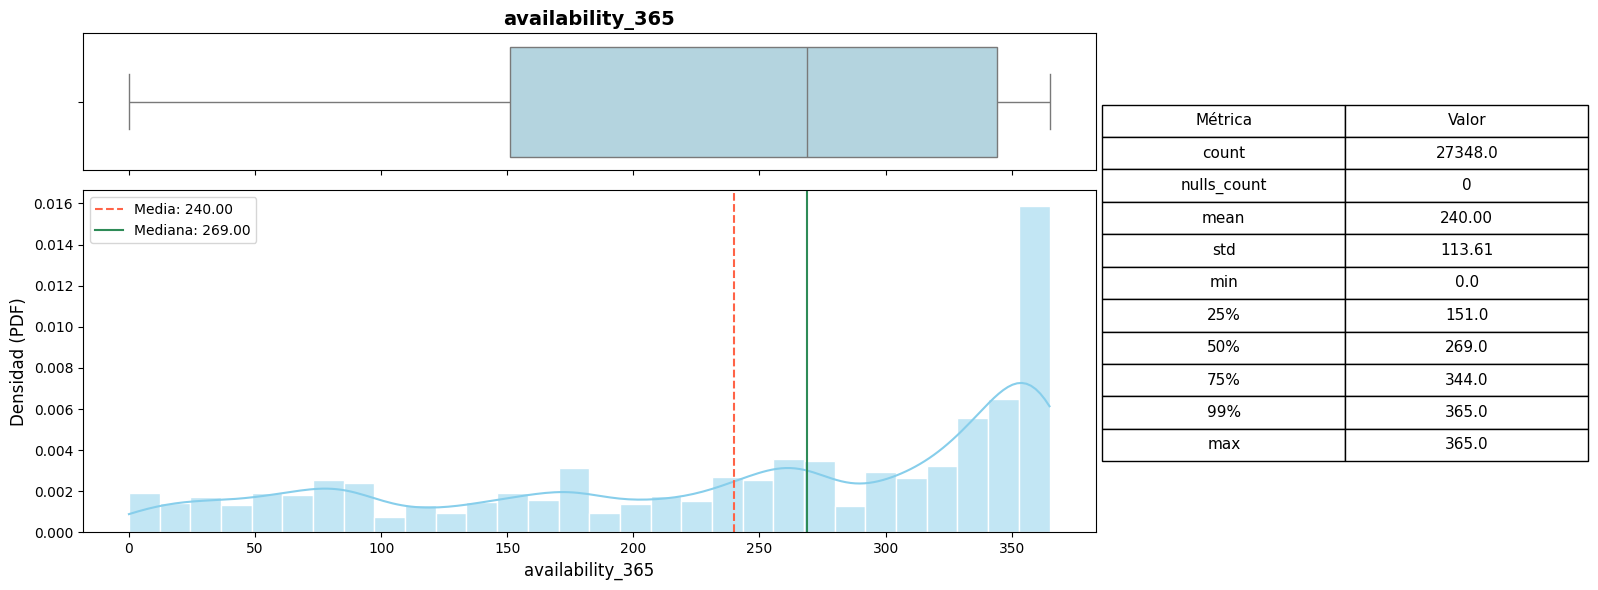

In [ ]:
plot_distribution(data, "availability_365")

#### 2.5.1 Verificación de Antigüedad
* Por definición de la variable Target, solo nos quedaremos con propiedades listadas hace más de 365 días
* La fecha del scrap fue el 25-01-2026, nos quedamos con las publicaciones con fecha previa al 25-01-2025
* Usamos la variable "first_review" como proxy de la fecha de publicación, aunque corremos el riesgo de sesgar la muestra ya que solo tendremos en cuenta propiedades con reviews


In [ ]:
first_review_before_umbral = (data['first_review'] <= '2025-01-25').sum()
total_registros = data.shape[0]

print(f'La base dispone de {total_registros} registros de los cuales solo {first_review_before_umbral} seran includios en el analisis')

data = data.query("first_review <= '2025-01-25'")



La base dispone de 27348 registros de los cuales solo 18722 seran includios en el analisis


#### 2.5.2 Distribución del Target post-filtro
* Por definición de la variable Target, solo nos quedaremos con propiedades listadas hace más de 365 días
* La fecha del scrap fue el 25-01-2026, nos quedamos con las publicaciones con fecha previa al 25-01-2025
* Usamos la variable "first_review" como proxy de la fecha de publicación, aunque corremos el riesgo de sesgar la muestra ya que solo tendremos en cuenta propiedades con reviews


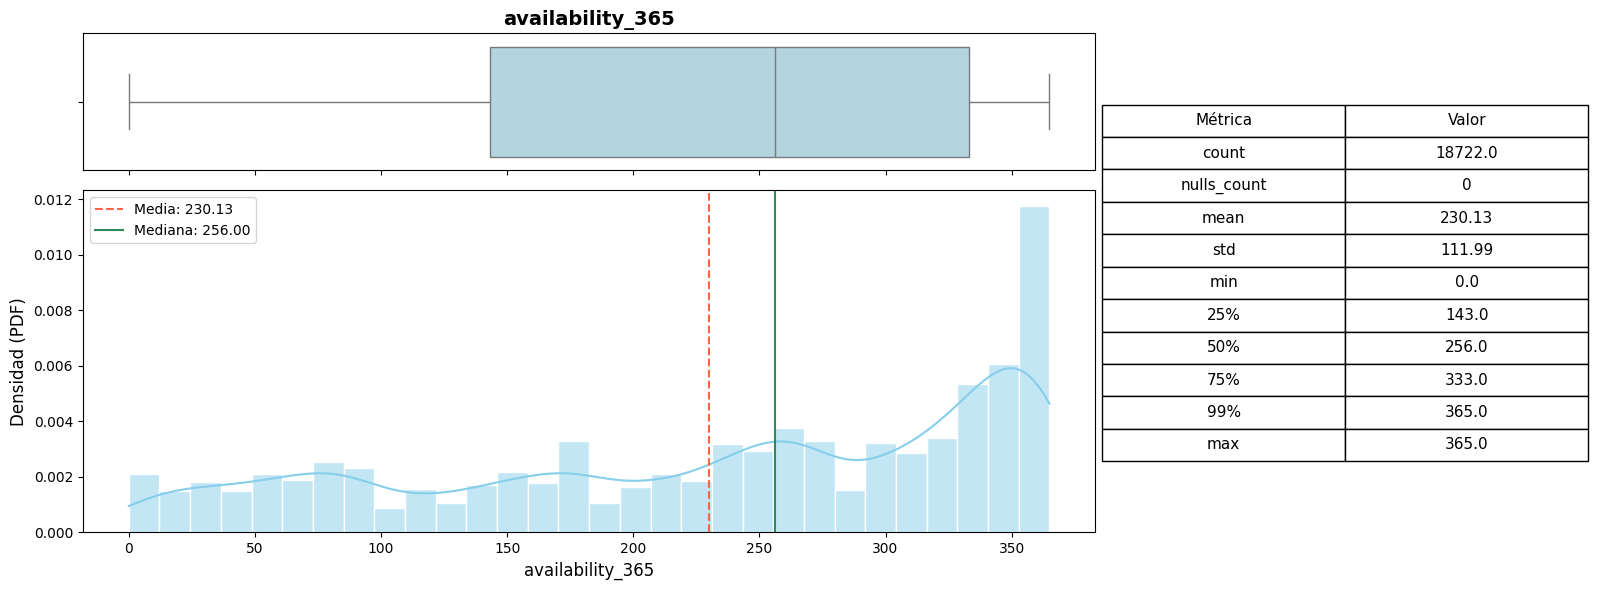

In [ ]:
plot_distribution(data, "availability_365")

### 2.6 Análisis de Valores Faltantes
* Identificación de valores faltantes y su tipo



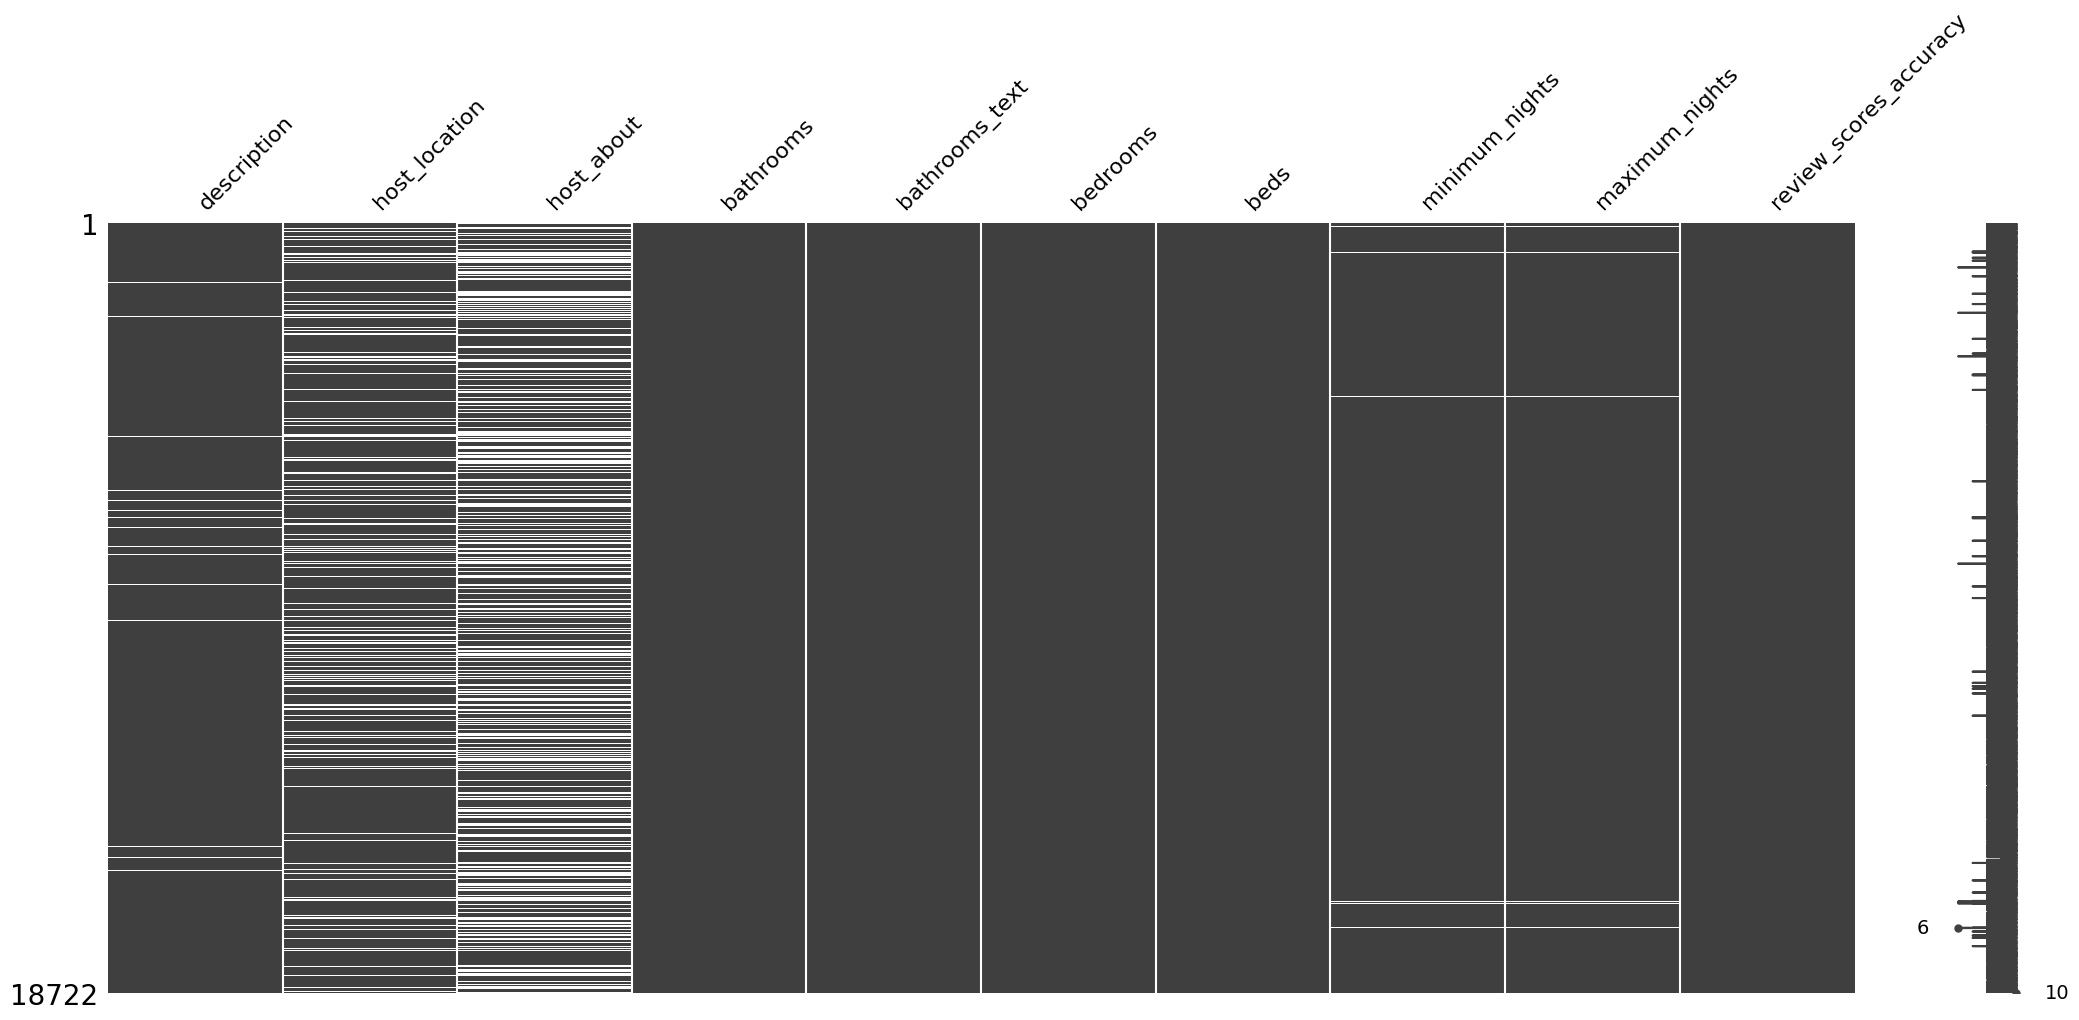

In [ ]:
# Muestra solo las columnas que tienen al menos un nulo
nulos_por_columna = data.columns[data.isnull().any()]
msno.matrix(data[nulos_por_columna])
plt.show()

# Muchisimos nulos sobre el host (about y location)

In [ ]:
null_counts_df = data.isnull().sum().to_frame(name='null_count')
display(null_counts_df[null_counts_df['null_count'] > 0])

,null_count
description,381
host_location,3080
host_about,7204
bathrooms,3
bathrooms_text,6
bedrooms,10
beds,6
minimum_nights,66
maximum_nights,66
review_scores_accuracy,1


In [ ]:
# Identificar columnas con 10 o menos nulos y borrarlos

columns_to_dropna = null_counts_df[null_counts_df['null_count'] <= 10].index.tolist()

# Eliminar filas con nulos en las columnas identificadas
initial_rows = data.shape[0]
data.dropna(subset=columns_to_dropna, inplace=True)

# Mostrar el efecto de la eliminación
final_rows = data.shape[0]
print(f"Filas eliminadas: {initial_rows - final_rows}")

# Verificar los nulos restantes
null_counts_after_drop = data.isnull().sum().to_frame(name='null_count')
display(null_counts_after_drop[null_counts_after_drop['null_count'] > 0])

Filas eliminadas: 22


,null_count
description,376
host_location,3078
host_about,7200
minimum_nights,66
maximum_nights,66


### 2.7 Análisis de Correlaciones
* Habría que haberlo hecho después del split, igual el impacto de haberlo hecho antes es casi nulo


#### 2.7.1 Correlación de Pearson
* Identificación de valores linealmente correlacionadas


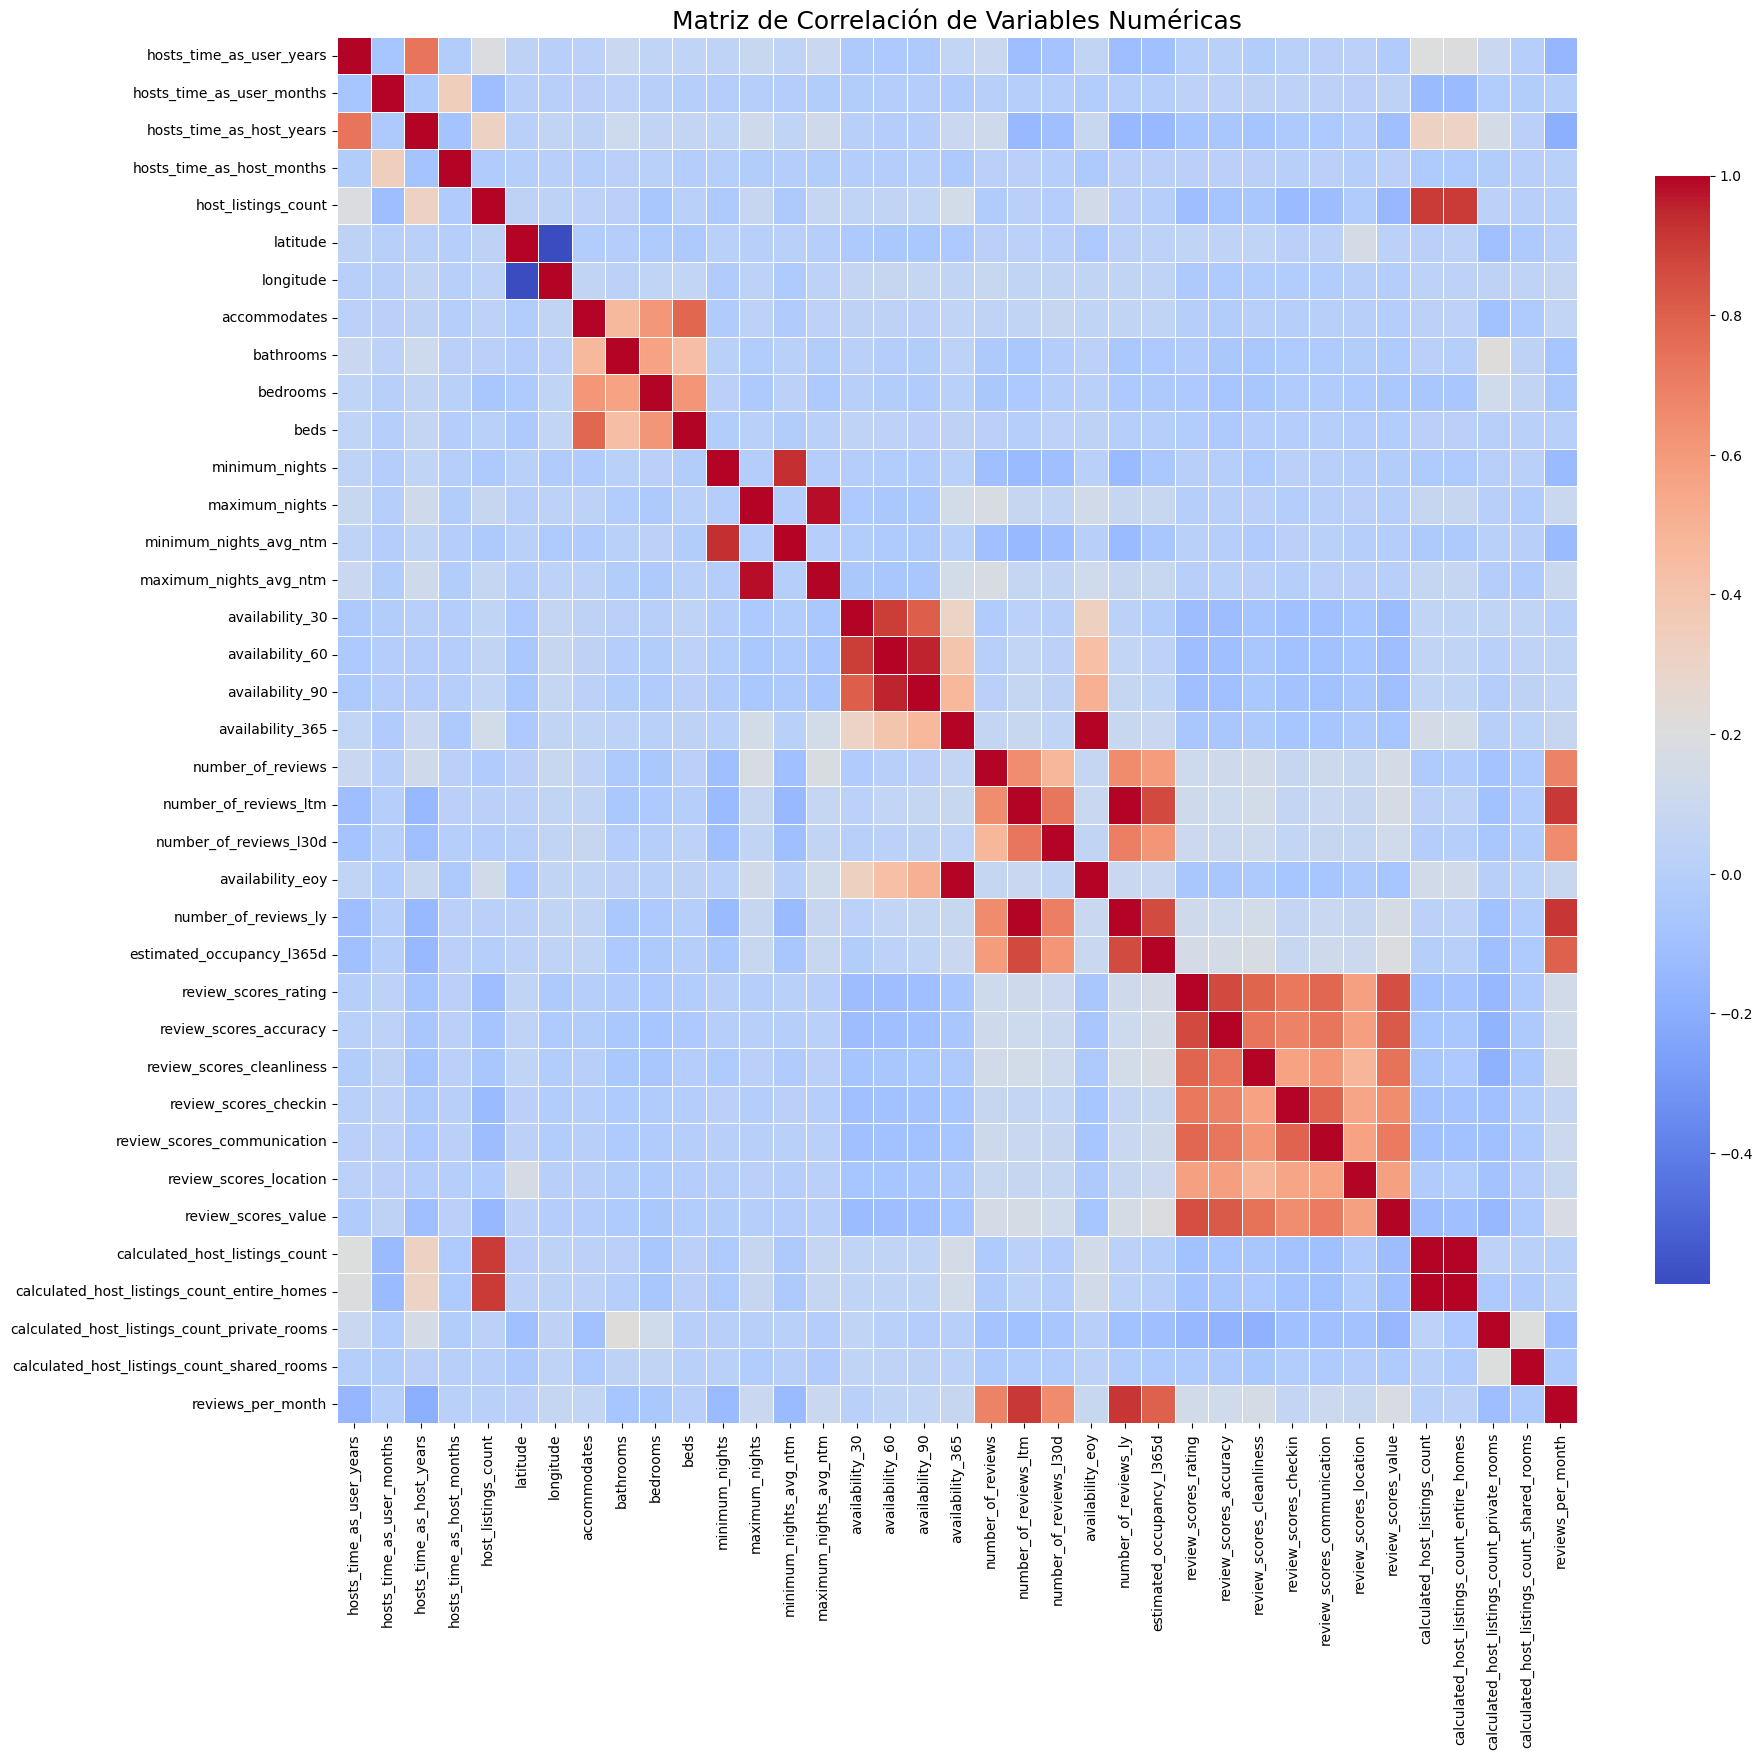

In [ ]:
corr_matrix = data.corr(numeric_only=True)

# # Creamos una máscara para el triángulo superior
# mask = np.triu(corr_matrix)

plt.figure(figsize=(20, 18))
sns.heatmap(corr_matrix, annot=False, cmap='coolwarm', fmt=".2f", linewidths=.5, cbar_kws={'shrink': .8}) #mask=mask,
plt.title('Matriz de Correlación de Variables Numéricas', fontsize=18)
plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.show()

In [ ]:
# Identificamos las variables con un coeficiente de correlación absoluto mayor a 0.7 o menor a -0.7

# Filtramos las correlaciones que son mayores a 0.7 o menores a -0.7, y que no son la correlación de una variable consigo misma
high_corr = corr_matrix[(corr_matrix.abs() > 0.7) & (corr_matrix.abs() < 1.0)]

# Convertimos a formato 'long' para facilitar la lectura
stacked_corr = high_corr.stack().reset_index()
stacked_corr.columns = ['Variable_1', 'Variable_2', 'Correlacion']

# Eliminamos duplicados (ej. A-B y B-A son lo mismo, solo mostramos una vez)
stacked_corr = stacked_corr[stacked_corr['Variable_1'] < stacked_corr['Variable_2']]

# Redondeamos la columna 'Correlacion' a dos decimales
stacked_corr['Correlacion'] = stacked_corr['Correlacion'].round(2)

# Mostramos
display(stacked_corr.sort_values(by='Correlacion', ascending=False))

,Variable_1,Variable_2,Correlacion
18,number_of_reviews_ltm,number_of_reviews_ly,1.00
16,availability_365,availability_eoy,1.00
52,calculated_host_listings_count,calculated_host_listings_count_entire_homes,1.00
7,maximum_nights,maximum_nights_avg_ntm,0.99
13,availability_60,availability_90,0.96
6,minimum_nights,minimum_nights_avg_ntm,0.93
25,number_of_reviews_ly,reviews_per_month,0.92
20,number_of_reviews_ltm,reviews_per_month,0.91
10,availability_30,availability_60,0.90
51,calculated_host_listings_count,host_listings_count,0.90


In [ ]:
# Seleccionamos las variables altamente correlacionadas, una del par

columns_corr_to_drop = [
    'number_of_reviews_ly',
    'availability_eoy',
    'maximum_nights_avg_ntm',
    'calculated_host_listings_count_entire_homes',
    'minimum_nights_avg_ntm',
    'maximum_nights_avg_ntm',
    #'minimum_maximum_nights',
    'minimum_nights_avg_ntm',
    'availability_60',
    'accommodates',
    #'maximum_minimum_nights',
    'estimated_occupancy_l365d',
    'review_scores_accuracy',
    'estimated_occupancy_l365d',
    'review_scores_value',
    'calculated_host_listings_count',
    'calculated_host_listings_count_entire_homes',
    'number_of_reviews_ly',
    'review_scores_cleanliness',
    'review_scores_communication',
    #'hosts_time_as_user_years',
    'number_of_reviews_l30d',
    'estimated_occupancy_l365d',
    'number_of_reviews_ltm',
    'availability_30',
    'review_scores_checkin'
]

# Las dropeamos
data.drop(columns=columns_corr_to_drop, inplace=True)

print(f'Cantidad de variables eliminadas por alta correlacion: {len(columns_corr_to_drop)}\n')
print("Resumen de tipos de datos actualizado:")
print(data.dtypes.value_counts())

Cantidad de variables eliminadas por alta correlacion: 23

Resumen de tipos de datos actualizado:
object            13
int64             10
float64           10
datetime64[ns]     2
Name: count, dtype: int64


## 3 División del dataset

* División en **X**, **y**.
* División en **Train**, **Test**.

In [ ]:
X = data.drop('availability_365', axis=1)
y = data['availability_365']

X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42)

### 3.1 Mutial Information
* Complemento al test de Pearson, para ver si se paso alguna que genere un Leakage

In [ ]:

X_train_numeric = X_train.select_dtypes(include=np.number)
X_test_numeric = X_test.select_dtypes(include=np.number)


X_train_numeric_no_na = X_train_numeric.dropna()
y_train_filtered = y_train.loc[X_train_numeric_no_na.index]

mi_scores = mutual_info_regression(X_train_numeric_no_na, y_train_filtered, random_state=42)
mi_df = pd.Series(mi_scores, index=X_train_numeric_no_na.columns).sort_values(ascending=False)
print(mi_df)

availability_90                                 2.443659
host_listings_count                             0.124402
latitude                                        0.061767
longitude                                       0.058481
reviews_per_month                               0.050715
maximum_nights                                  0.040494
number_of_reviews                               0.038371
calculated_host_listings_count_private_rooms    0.033087
hosts_time_as_user_years                        0.030026
review_scores_rating                            0.029685
hosts_time_as_host_years                        0.024697
review_scores_location                          0.017543
minimum_nights                                  0.015969
hosts_time_as_user_months                       0.014244
bedrooms                                        0.013597
bathrooms                                       0.012652
beds                                            0.009881
calculated_host_listings_count_

In [ ]:
# Leakage
leakage_cols = ['availability_90']

# Información casi nula, igual no las dropamos
low_mi_cols = ['bathrooms', 'bedrooms']

# Solo dropeamos availability_90
X_train.drop(columns=leakage_cols, inplace=True)
X_test.drop(columns=leakage_cols, inplace=True)

## 4 Tratamiento de Datos


### 4.1. Enteros

In [ ]:
columns_int = X_train.select_dtypes(include=['int']).columns.tolist()
display(columns_int)

['hosts_time_as_user_years',
 'hosts_time_as_user_months',
 'hosts_time_as_host_years',
 'hosts_time_as_host_months',
 'host_listings_count',
 'number_of_reviews',
 'calculated_host_listings_count_private_rooms',
 'calculated_host_listings_count_shared_rooms']

#### 4.1.1 Variable: hosts_time_as_user_years

hosts_time_as_user_years: 0 NULLS


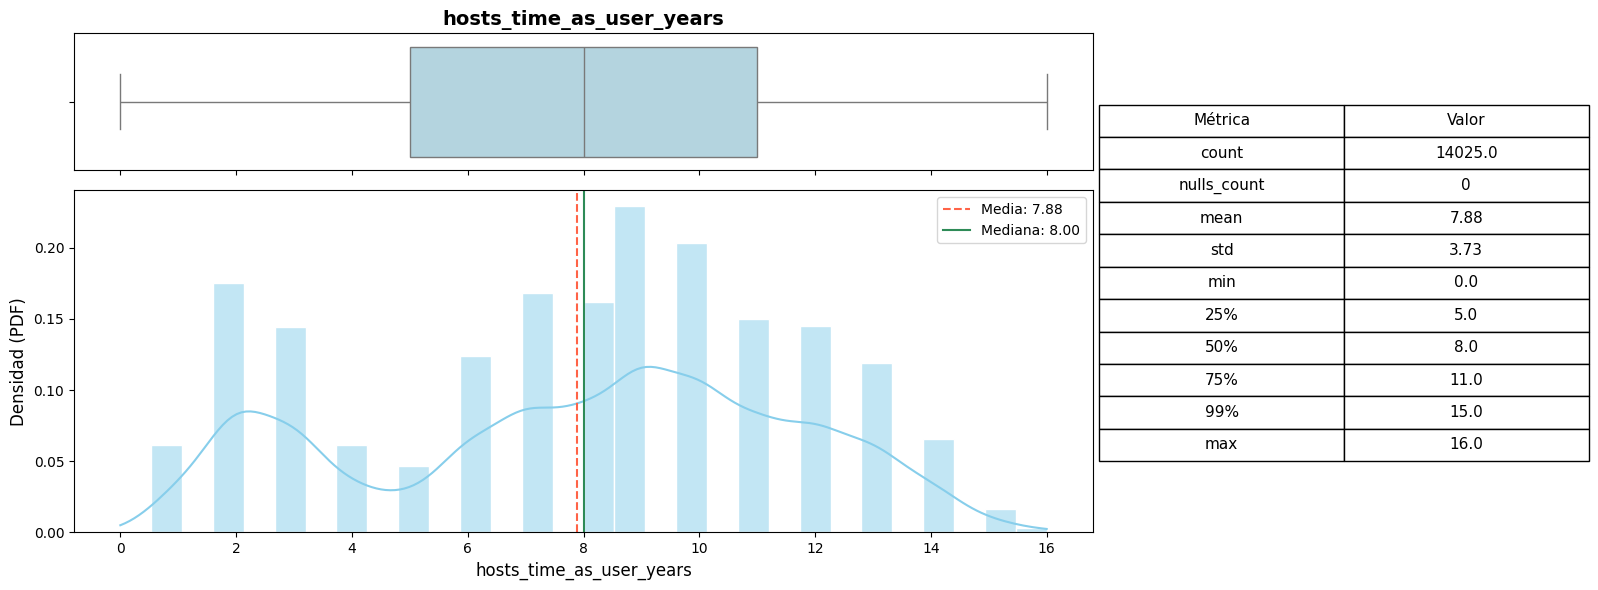

In [ ]:
variable = 'hosts_time_as_user_years'

print(f'{variable}: {X_train[variable].isnull().sum()} NULLS')
plot_distribution(X_train, variable)

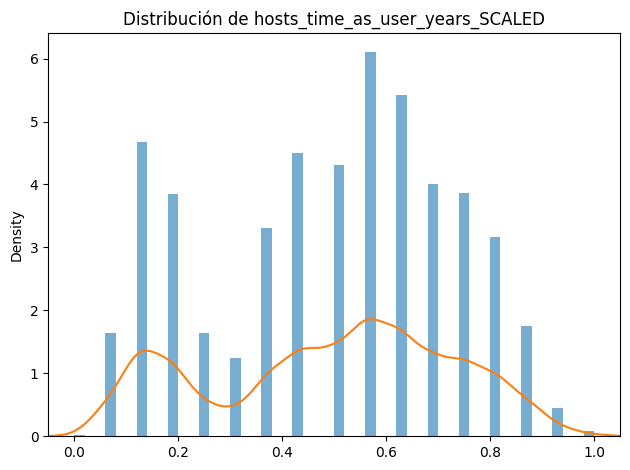

✅ 'hosts_time_as_user_years' → 'hosts_time_as_user_years_SCALED' | Min: 0.0000 | Max: 1.0000 | Mean: 0.4927


In [ ]:
transform_scaler(variable)

#### 4.1.2 Variable: hosts_time_as_user_months

hosts_time_as_user_months: 0 NULLS


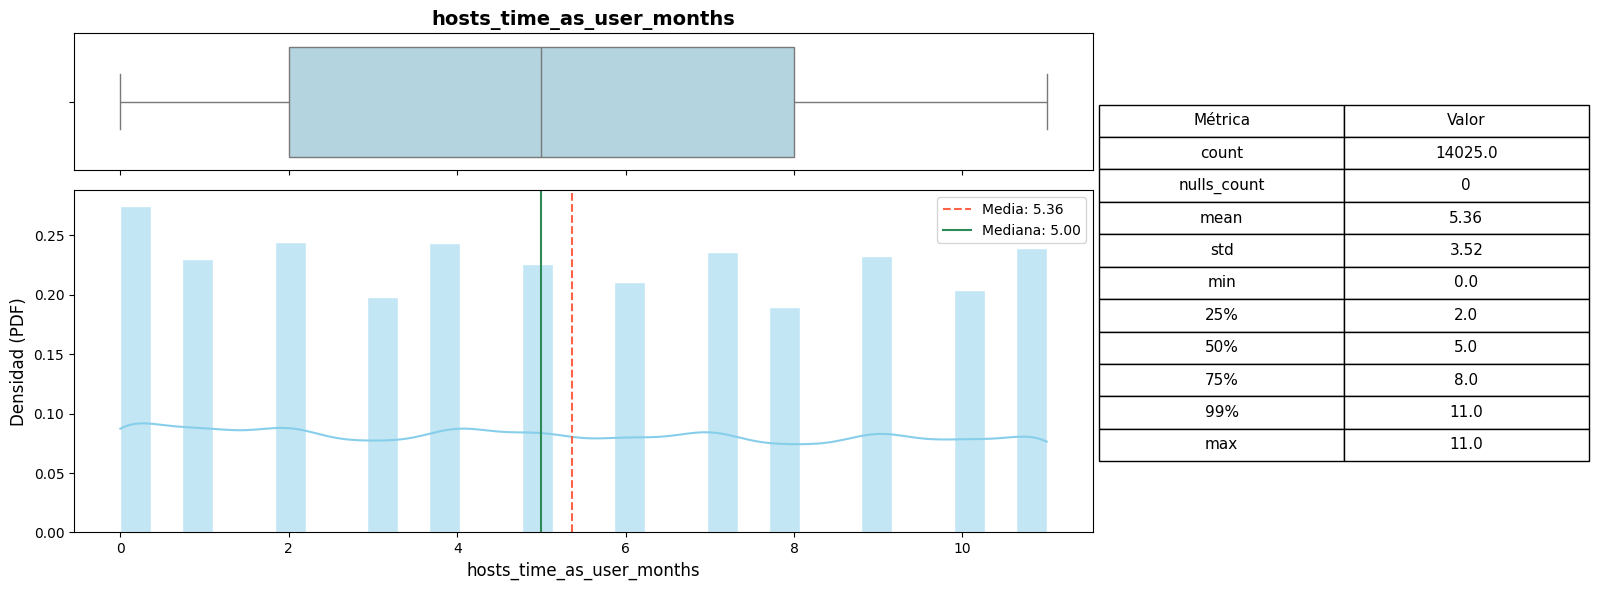

In [ ]:
variable = 'hosts_time_as_user_months'

print(f'{variable}: {X_train[variable].isnull().sum()} NULLS')
plot_distribution(X_train, variable)

In [ ]:
drop_non_relevant(variable)

✅ 'hosts_time_as_user_months' → DROP de Train y Test


#### 4.1.3 Variable: hosts_time_as_host_years

hosts_time_as_host_years: 0 NULLS


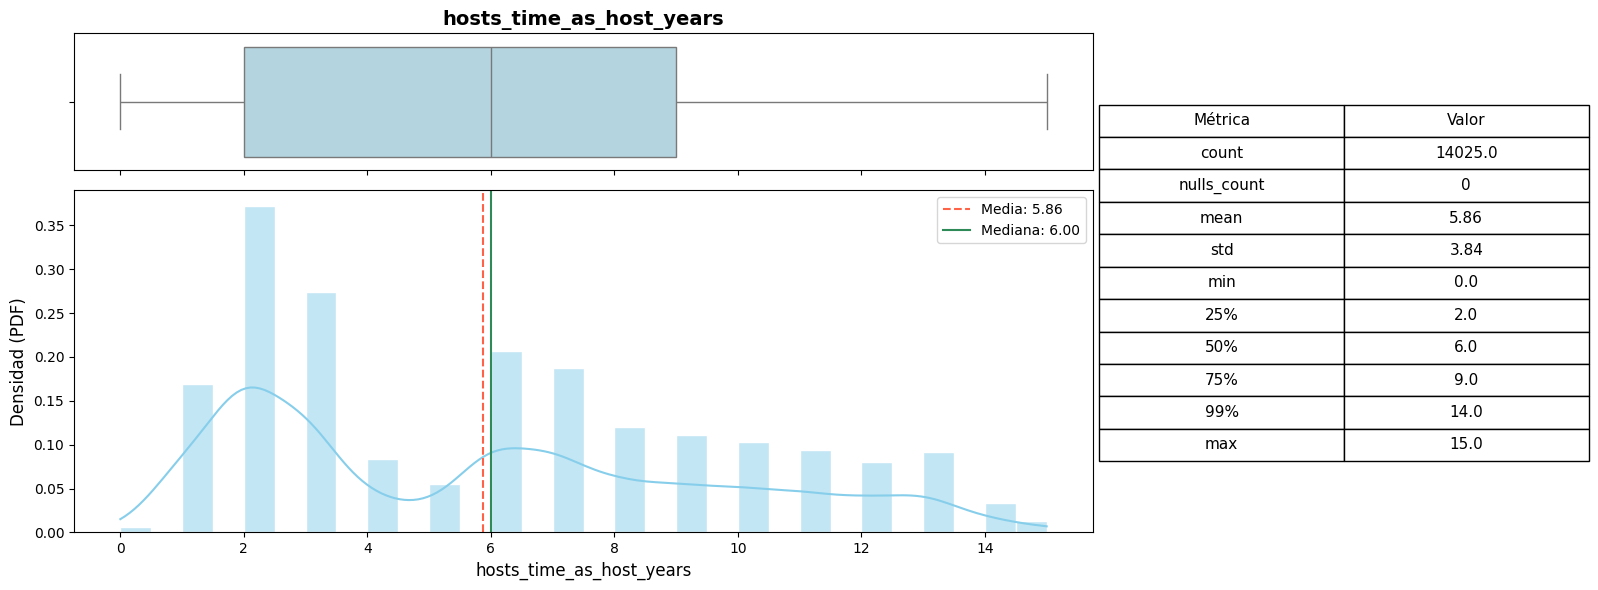

In [ ]:
variable = 'hosts_time_as_host_years'

print(f'{variable}: {X_train[variable].isnull().sum()} NULLS')
plot_distribution(X_train, variable)

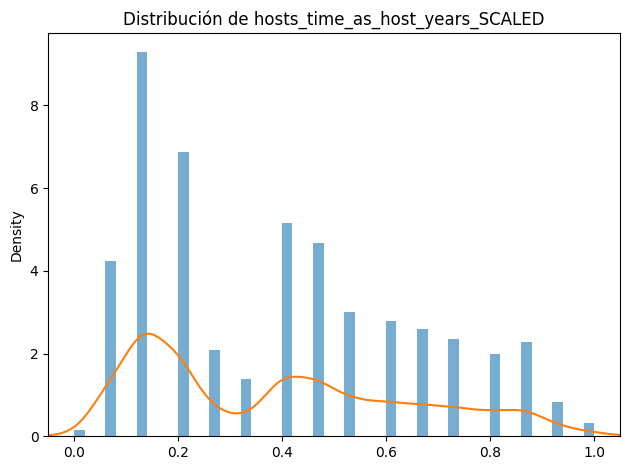

✅ 'hosts_time_as_host_years' → 'hosts_time_as_host_years_SCALED' | Min: 0.0000 | Max: 1.0000 | Mean: 0.3910


In [ ]:
transform_scaler(variable)

#### 4.1.4 Variable: hosts_time_as_host_months

hosts_time_as_host_months: 0 NULLS


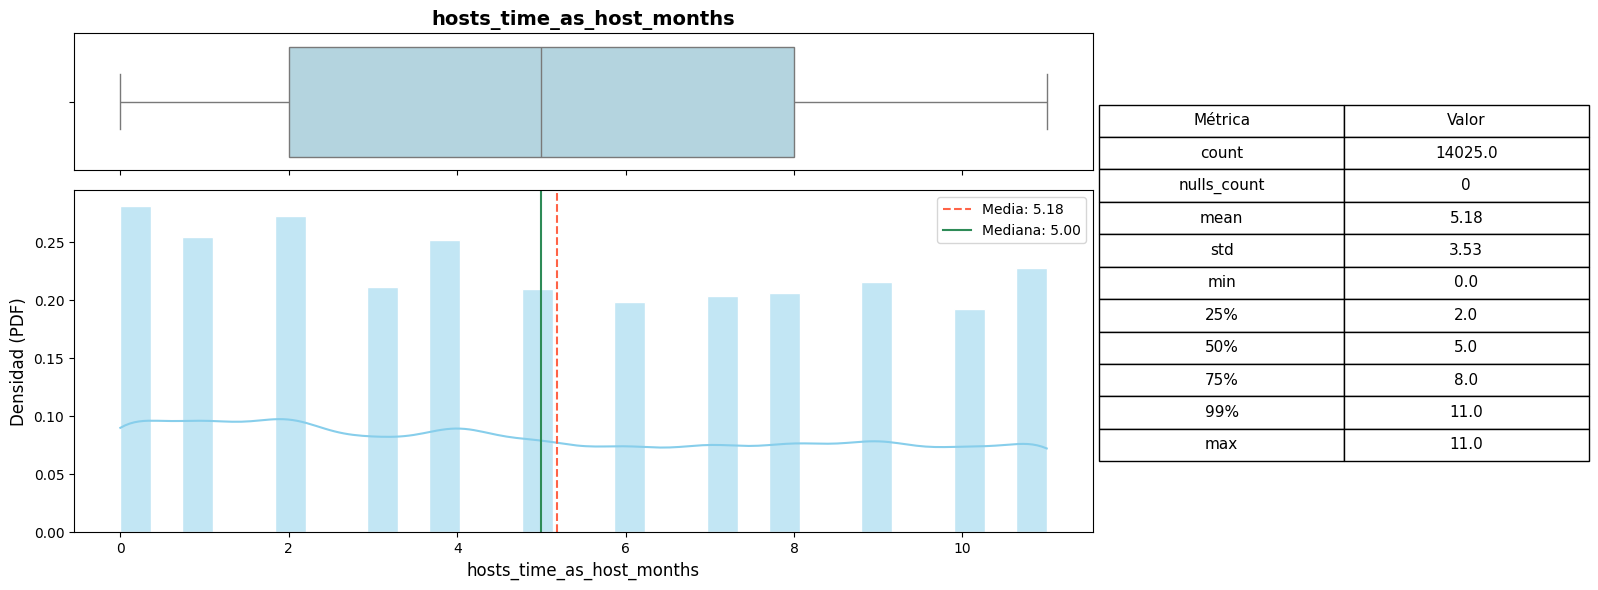

In [ ]:
variable = 'hosts_time_as_host_months'

print(f'{variable}: {X_train[variable].isnull().sum()} NULLS')
plot_distribution(X_train, variable)

In [ ]:
drop_non_relevant(variable)

✅ 'hosts_time_as_host_months' → DROP de Train y Test


#### 4.1.5 Variable: host_listings_count

host_listings_count: 0 NULLS


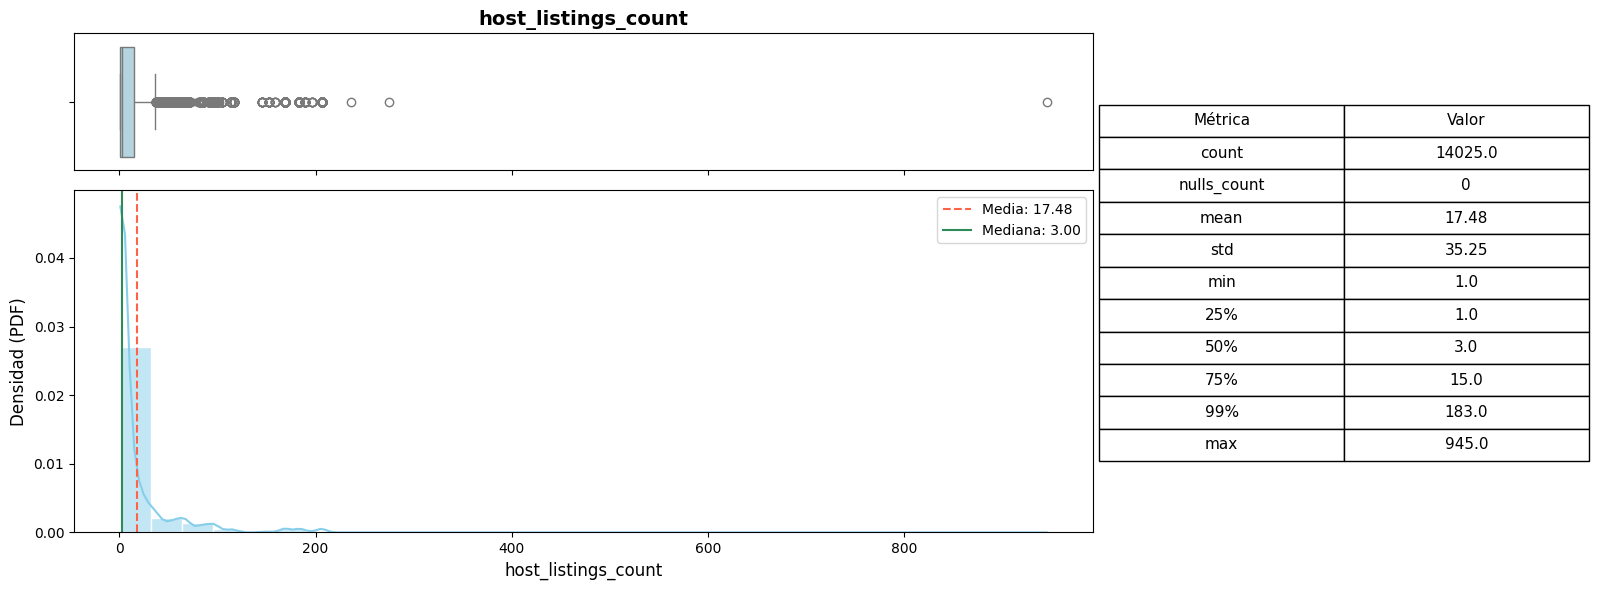

In [ ]:
variable = 'host_listings_count'

print(f'{variable}: {X_train[variable].isnull().sum()} NULLS')
plot_distribution(X_train, variable)

In [ ]:
analize_capping(variable)


📊 Variable: 'host_listings_count'


,Percentil,Valor,N casos (> p),Δ vs anterior,Δ% vs anterior
0,p90,55.0,1391,NaN,nan%
1,p91,61.0,1243,6.0,10.91%
2,p92,64.0,1116,3.0,4.92%
3,p93,70.0,975,6.0,9.38%
4,p94,82.0,823,12.0,17.14%
5,p95,84.0,700,2.0,2.44%
6,p96,95.0,540,11.0,13.1%
7,p97,114.0,364,19.0,20.0%
8,p98,169.0,210,55.0,48.25%
9,p99,206.0,3,37.0,21.89%


✅ 'host_listings_count' capeada en p97 → umbral = 114.0000 (X_train)
✅ 'host_listings_count' capeada en p97 → umbral = 114.0000 (X_test)


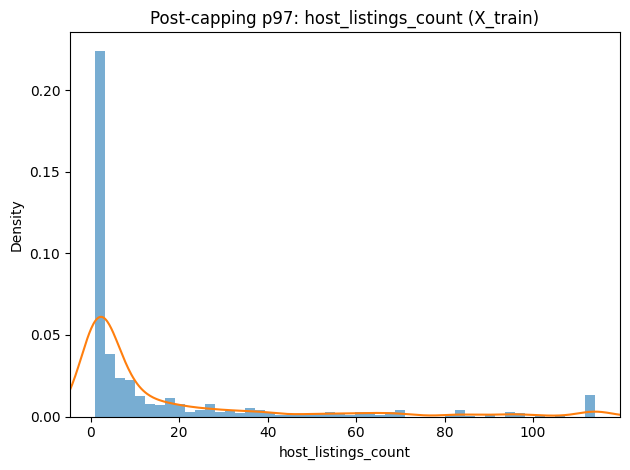

np.float64(114.0)

In [ ]:
transform_capping(variable, 97)

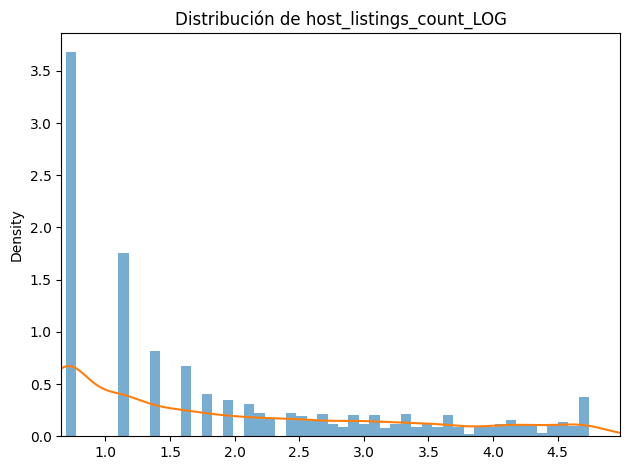

✅ 'host_listings_count' → 'host_listings_count_LOG' | Min: 0.6931 | Max: 4.7449 | Mean: 1.9071


In [ ]:
transform_log(variable)

#### 4.1.6 Variable: availability_30

In [ ]:
# variable = 'availability_30'

# print(f'{variable}: {X_train[variable].isnull().sum()} NULLS')
# plot_distribution(X_train, variable)

#### 4.1.7 Variable: availability_60

In [ ]:
# variable = 'availability_60'

# print(f'{variable}: {X_train[variable].isnull().sum()} NULLS')
# plot_distribution(X_train, variable)

#### 4.1.8 Variable: availability_90

In [ ]:
# # La dropeamos por leakage
# variable = 'availability_90'

# print(f'{variable}: {X_train[variable].isnull().sum()} NULLS')
# plot_distribution(X_train, variable)

In [ ]:
# transform_scaler(variable)

#### 4.1.9 Variable: availability_365 (nuevo target)

In [ ]:
# variable = 'availability_365'

# print(f'{variable}: {X_train[variable].isnull().sum()} NULLS')
# plot_distribution(X_train, variable)

# # Escalamos
# columns_to_scale.append(variable)

#### 4.1.10 Variable: number_of_reviews

number_of_reviews: 0 NULLS


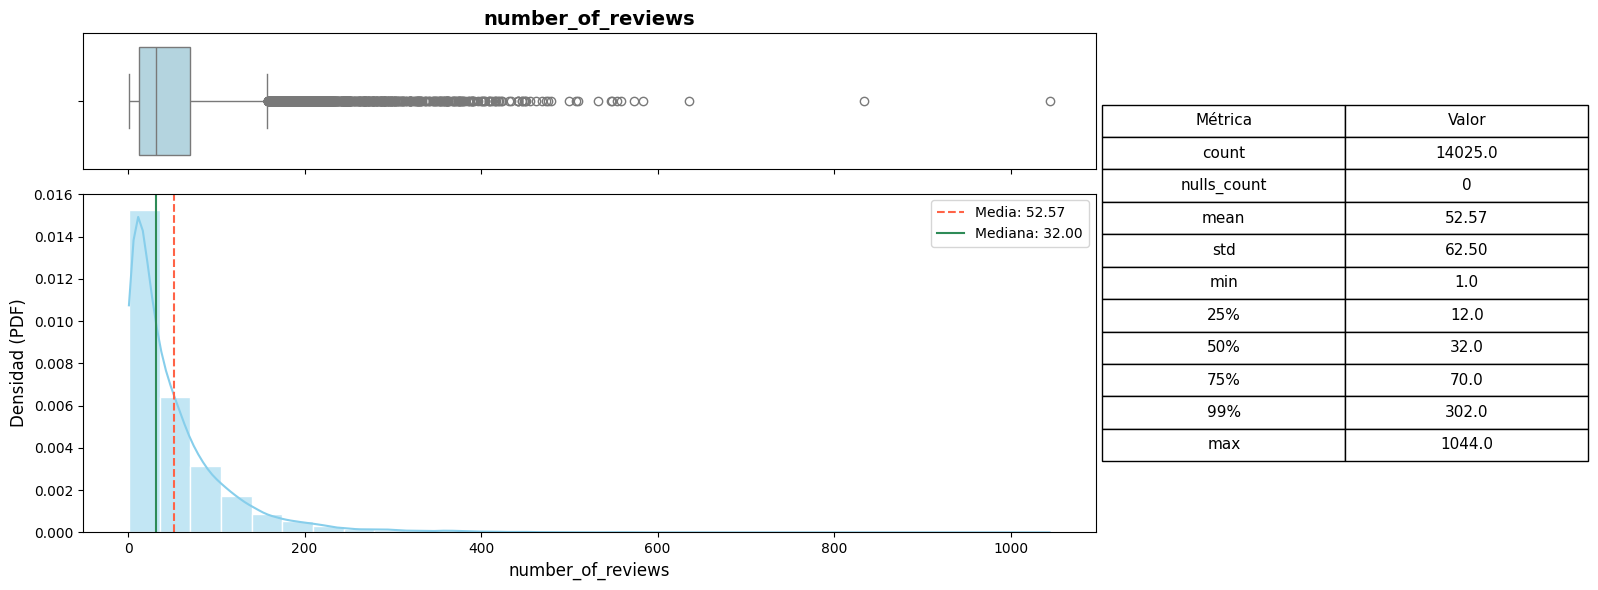

In [ ]:
variable = 'number_of_reviews'

print(f'{variable}: {X_train[variable].isnull().sum()} NULLS')
plot_distribution(X_train, variable)

In [ ]:
analize_capping(variable)


📊 Variable: 'number_of_reviews'


,Percentil,Valor,N casos (> p),Δ vs anterior,Δ% vs anterior
0,p90,124.00,1396,NaN,nan%
1,p91,130.00,1257,6.00,4.84%
2,p92,138.00,1120,8.00,6.15%
3,p93,146.00,980,8.00,5.8%
4,p94,157.00,839,11.00,7.53%
5,p95,170.00,699,13.00,8.28%
6,p96,187.00,556,17.00,10.0%
7,p97,208.00,419,21.00,11.23%
8,p98,241.00,279,33.00,15.87%
9,p99,367.64,71,126.64,52.55%


✅ 'number_of_reviews' capeada en p98 → umbral = 241.0000 (X_train)
✅ 'number_of_reviews' capeada en p98 → umbral = 241.0000 (X_test)


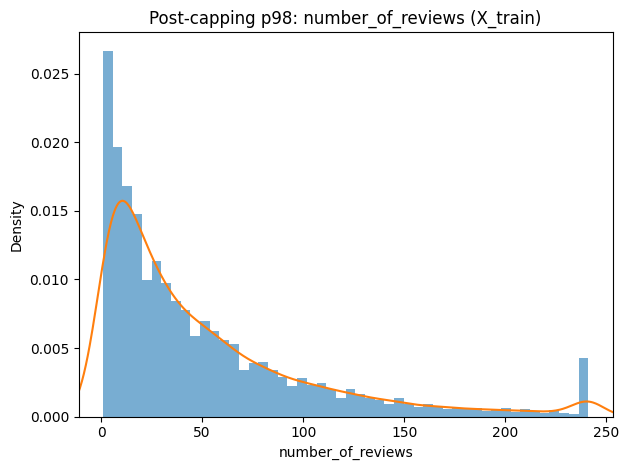

np.float64(241.0)

In [ ]:
transform_capping(variable, 98)

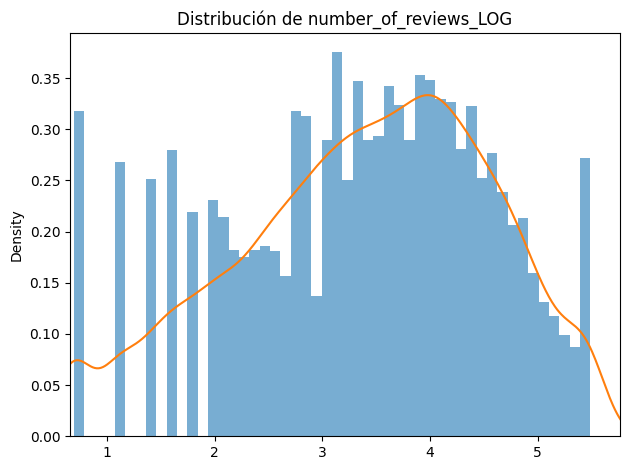

✅ 'number_of_reviews' → 'number_of_reviews_LOG' | Min: 0.6931 | Max: 5.4889 | Mean: 3.3695


In [ ]:
transform_log(variable)

#### 4.1.11 Variable: number_of_reviews_ltm

In [ ]:
# variable = 'number_of_reviews_ltm'

# print(f'{variable}: {X_train[variable].isnull().sum()} NULLS')
# plot_distribution(X_train, variable)

#### 4.1.12 Variable: number_of_reviews_l30d

In [ ]:
# variable = 'number_of_reviews_l30d'

# print(f'{variable}: {X_train[variable].isnull().sum()} NULLS')
# plot_distribution(X_train, variable)

#### 4.1.13 Variable: availability_eoy

In [ ]:
# variable = 'availability_eoy'

# print(f'{variable}: {X_train[variable].isnull().sum()} NULLS')
# plot_distribution(X_train, variable)

#### 4.1.14 Variable: number_of_reviews_ly

In [ ]:
# variable = 'number_of_reviews_ly'

# print(f'{variable}: {X_train[variable].isnull().sum()} NULLS')
# plot_distribution(X_train, variable)

#### 4.1.15 Variable: estimated_occupancy_l365d

In [ ]:
# variable = 'estimated_occupancy_l365d'

# print(f'{variable}: {X_train[variable].isnull().sum()} NULLS')
# plot_distribution(X_train, variable)

#### 4.1.16 Variable: calculated_host_listings_count

In [ ]:
# variable = 'calculated_host_listings_count'

# print(f'{variable}: {X_train[variable].isnull().sum()} NULLS')
# plot_distribution(X_train, variable)

#### 4.1.17 Variable: calculated_host_listings_count_entire_homes:

In [ ]:
# variable = 'calculated_host_listings_count_entire_homes'

# print(f'{variable}: {X_train[variable].isnull().sum()} NULLS')
# plot_distribution(X_train, variable)

#### 4.1.18 Variable: calculated_host_listings_count_private_rooms

calculated_host_listings_count_private_rooms: 0 NULLS


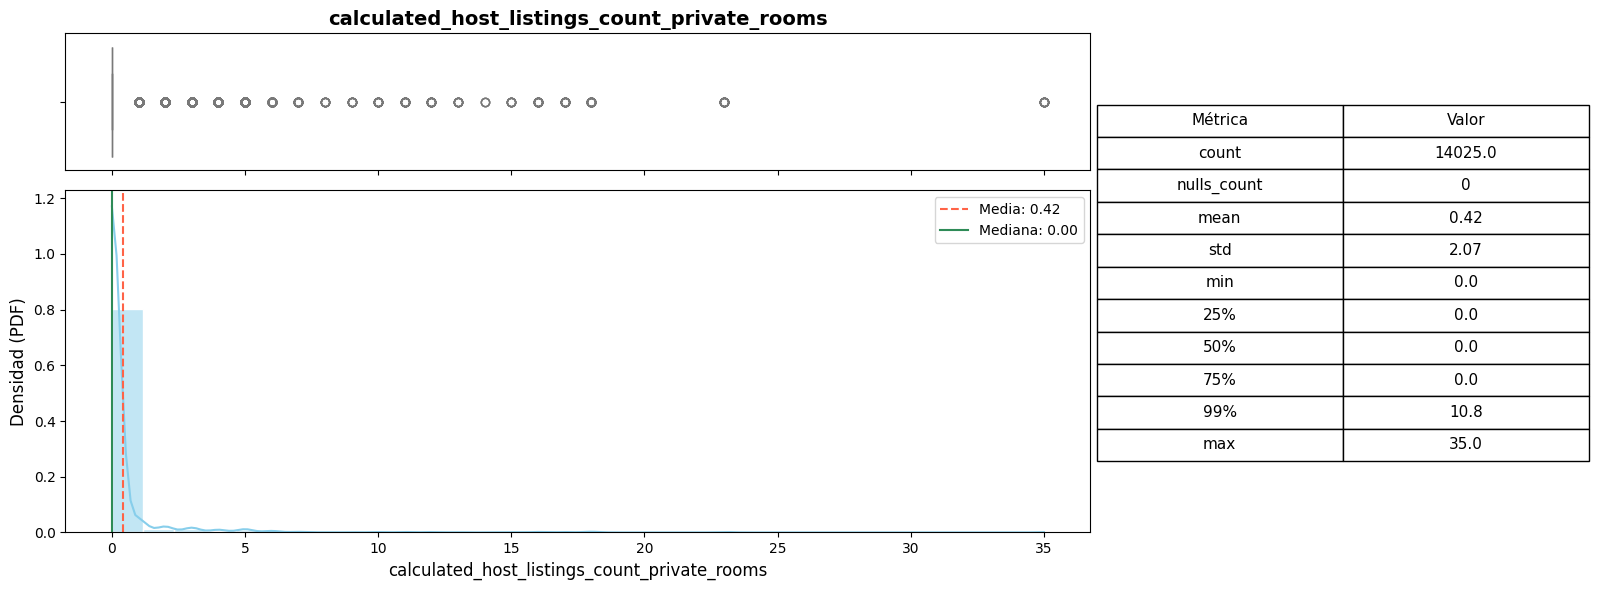

In [ ]:
variable = 'calculated_host_listings_count_private_rooms'

print(f'{variable}: {X_train[variable].isnull().sum()} NULLS')
plot_distribution(X_train, variable)

In [ ]:
# No entiendo la variable, me parece que la dropearia y me quedaria solo con la de years
drop_non_relevant(variable)

✅ 'calculated_host_listings_count_private_rooms' → DROP de Train y Test


#### 4.1.19 Variable: calculated_host_listings_count_shared_rooms

calculated_host_listings_count_shared_rooms: 0 NULLS


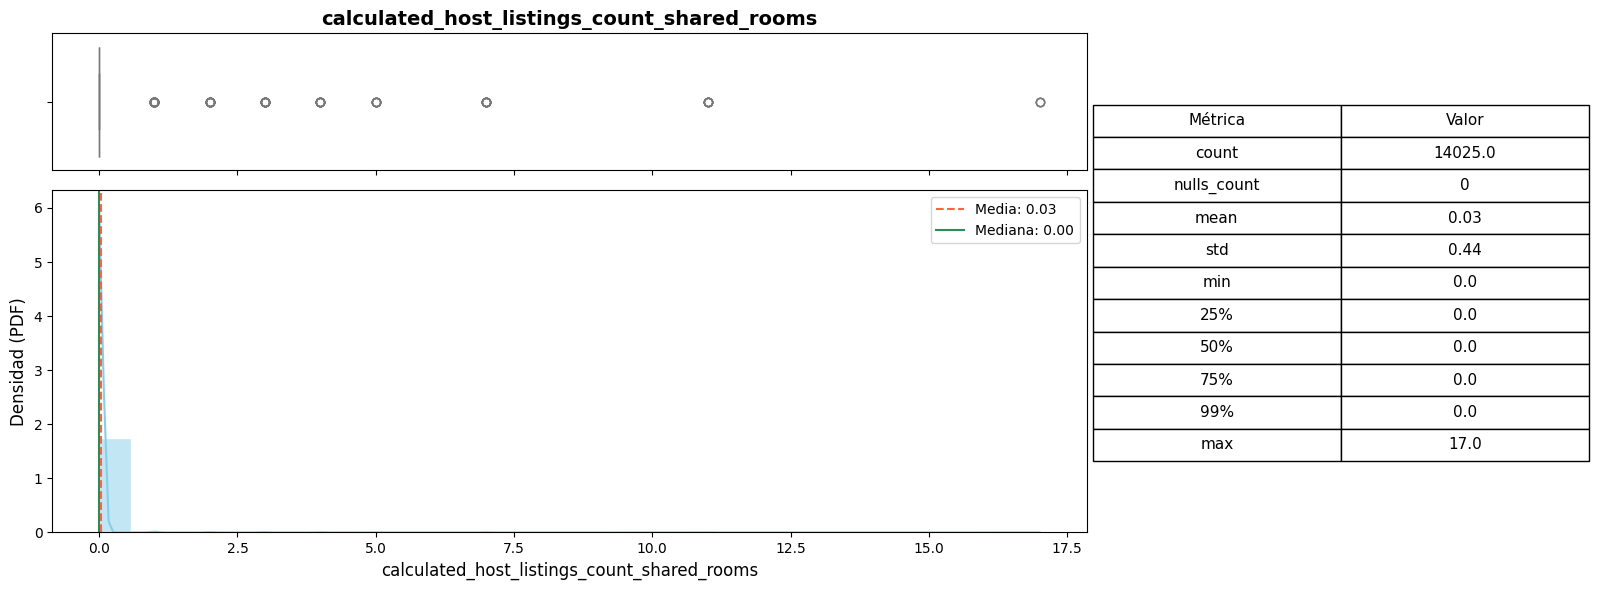

In [ ]:
variable = 'calculated_host_listings_count_shared_rooms'

print(f'{variable}: {X_train[variable].isnull().sum()} NULLS')
plot_distribution(X_train, variable)

In [ ]:
# No entiendo la variable, me parece que la dropearia y me quedaria solo con la de years
drop_non_relevant(variable)

✅ 'calculated_host_listings_count_shared_rooms' → DROP de Train y Test


### 4.2 Float

In [ ]:
columns_float = X_train.select_dtypes(include=['float']).columns.tolist()
columns_float

['latitude',
 'longitude',
 'bathrooms',
 'bedrooms',
 'beds',
 'minimum_nights',
 'maximum_nights',
 'review_scores_rating',
 'review_scores_location',
 'reviews_per_month',
 'hosts_time_as_user_years_SCALED',
 'hosts_time_as_host_years_SCALED',
 'host_listings_count_LOG',
 'number_of_reviews_LOG']

#### 4.2.1 Variable: latitude

latitude: 0 NULLS


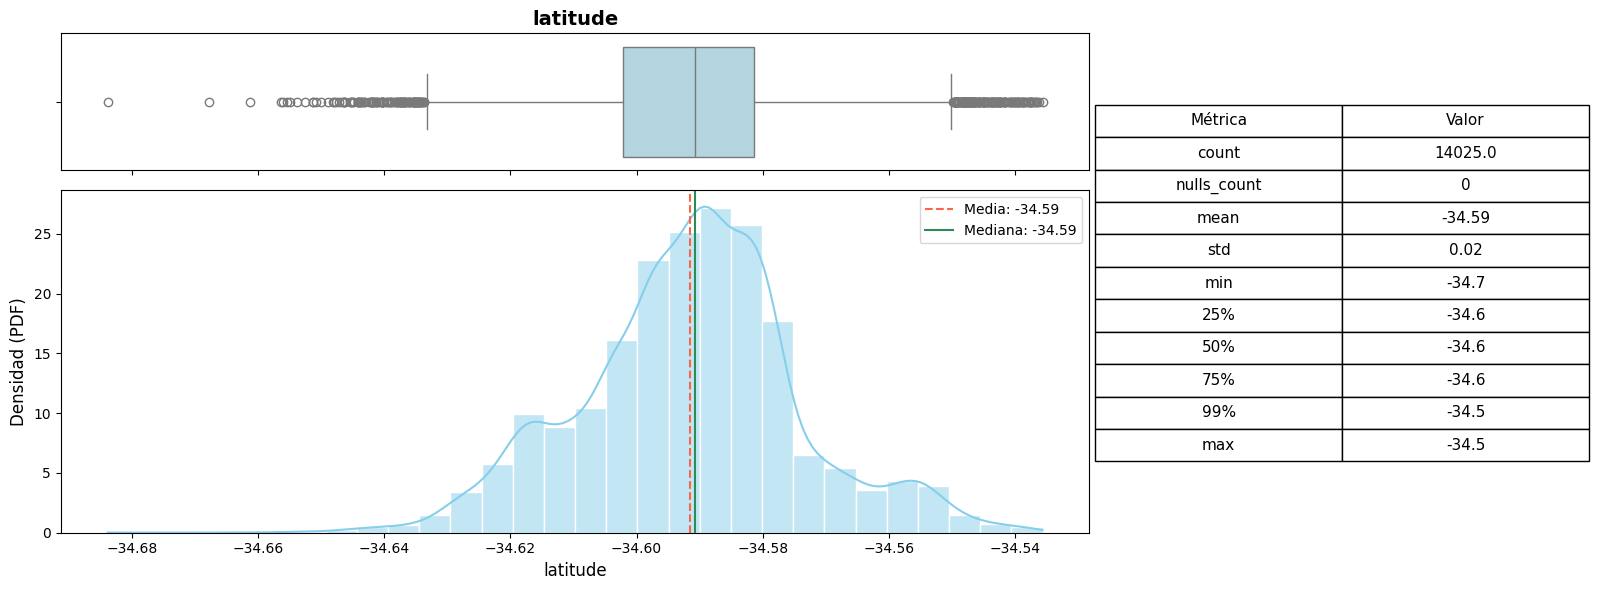

In [ ]:
variable = 'latitude'

print(f'{variable}: {X_train[variable].isnull().sum()} NULLS')
plot_distribution(X_train, variable)

variable_bkp = variable # Para plotear despues

#### 4.2.2 Variable: longitude


longitude: 0 NULLS


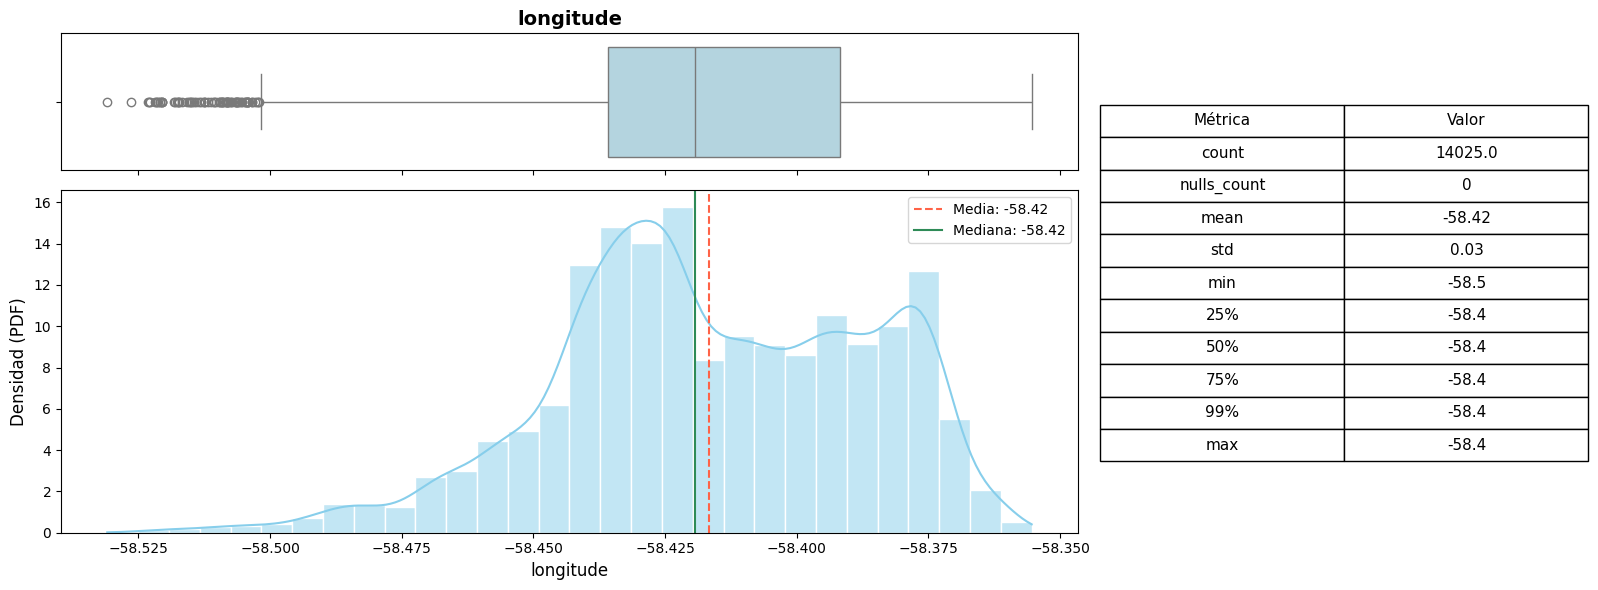

In [ ]:
variable = 'longitude'

print(f'{variable}: {X_train[variable].isnull().sum()} NULLS')
plot_distribution(X_train, variable)

In [ ]:
# Ploteamos los listing en un mapa de CABA


mapa = folium.Map(
    location=[-34.6037, -58.3816],
    zoom_start=12,
    tiles="CartoDB positron"
)

coords = X_train[["latitude", "longitude"]].dropna().values.tolist()
HeatMap(coords, radius=8, blur=10, min_opacity=0.3).add_to(mapa)


mapa



In [ ]:
# Dropeamos las coordenadas, ya que no se usaran para modeler

drop_non_relevant(variable)
drop_non_relevant(variable_bkp)

✅ 'longitude' → DROP de Train y Test
✅ 'latitude' → DROP de Train y Test


#### 4.2.3 Variable: bathrooms

bathrooms: 0 NULLS


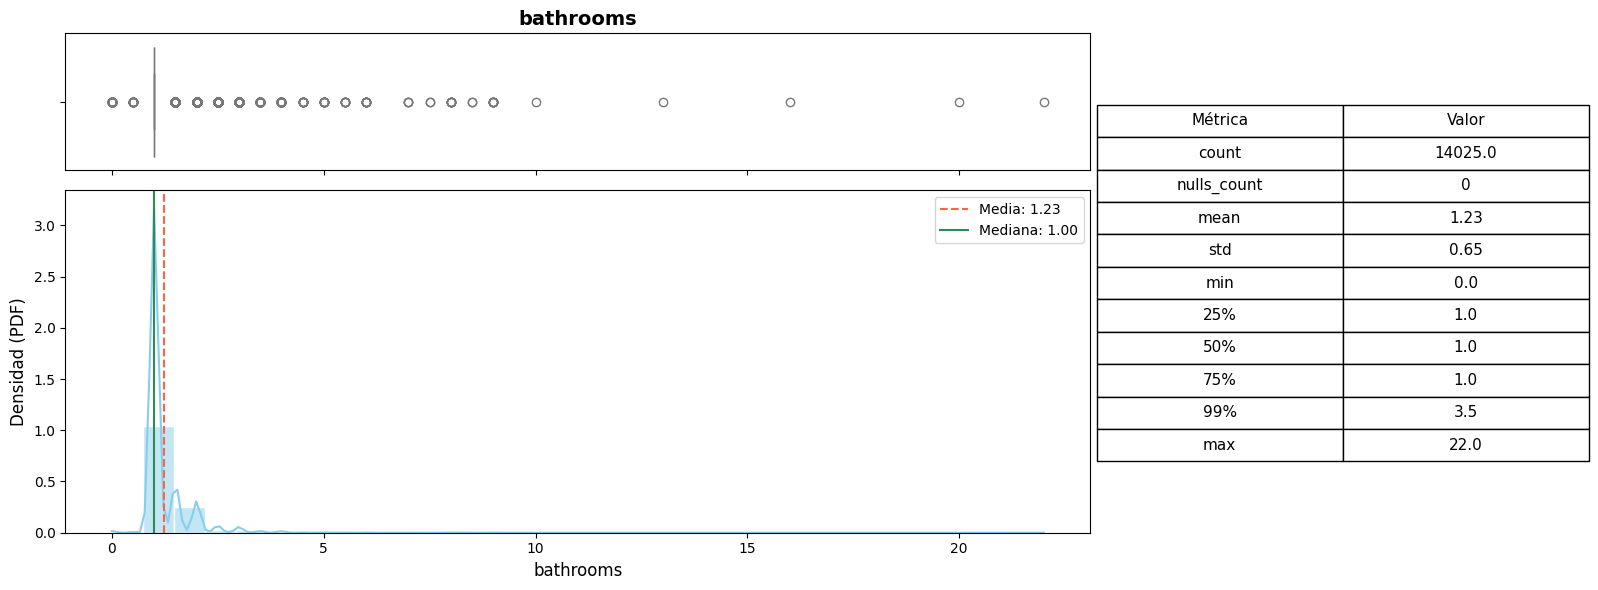

In [ ]:
variable = 'bathrooms'

print(f'{variable}: {X_train[variable].isnull().sum()} NULLS')
plot_distribution(X_train, variable)

In [ ]:
analize_capping(variable)


📊 Variable: 'bathrooms'


,Percentil,Valor,N casos (> p),Δ vs anterior,Δ% vs anterior
0,p90,2.0,587,NaN,nan%
1,p91,2.0,587,0.0,0.0%
2,p92,2.0,587,0.0,0.0%
3,p93,2.0,587,0.0,0.0%
4,p94,2.0,587,0.0,0.0%
5,p95,2.0,587,0.0,0.0%
6,p96,2.5,357,0.5,25.0%
7,p97,2.5,357,0.0,0.0%
8,p98,3.0,170,0.5,20.0%
9,p99,4.0,64,1.0,33.33%


✅ 'bathrooms' capeada en p99 → umbral = 3.5000 (X_train)
✅ 'bathrooms' capeada en p99 → umbral = 3.5000 (X_test)


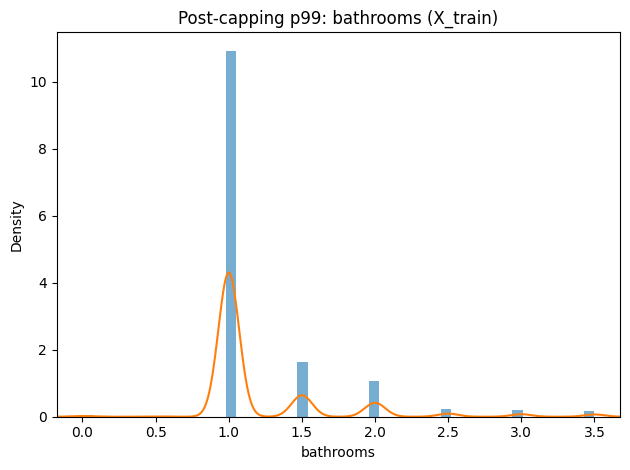

np.float64(3.5)

In [ ]:
transform_capping(variable, 99)

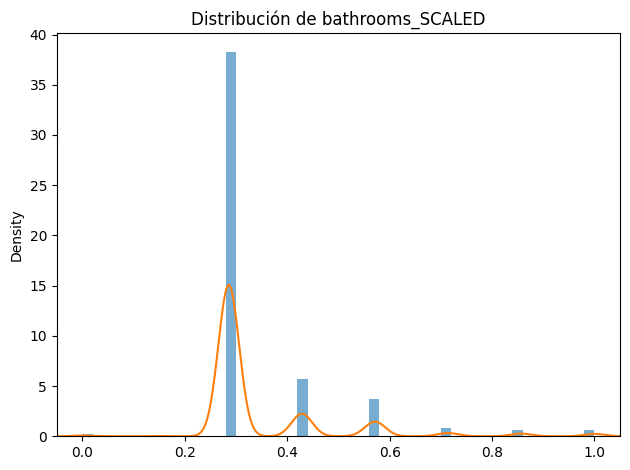

✅ 'bathrooms' → 'bathrooms_SCALED' | Min: 0.0000 | Max: 1.0000 | Mean: 0.3451


In [ ]:
transform_scaler(variable)

#### 4.2.4 Variable: bedrooms

bedrooms: 0 NULLS


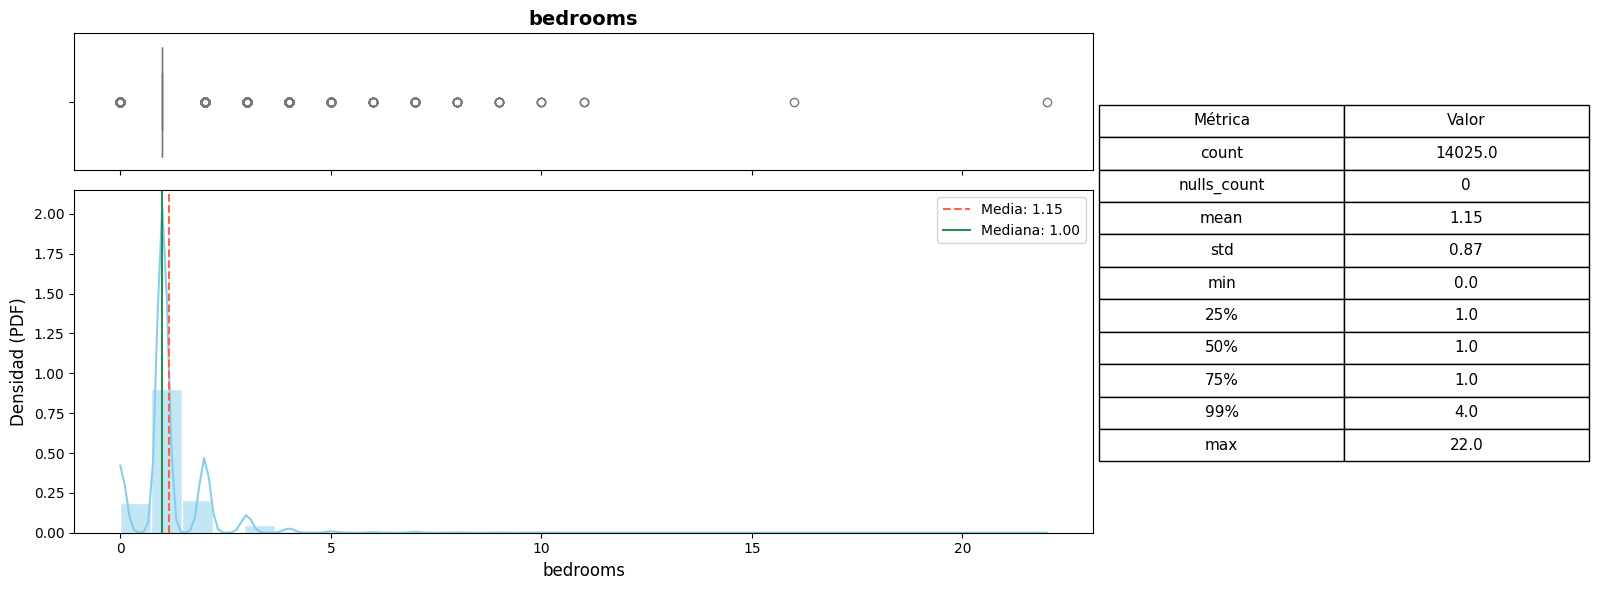

In [ ]:
variable = 'bedrooms'

print(f'{variable}: {X_train[variable].isnull().sum()} NULLS')
plot_distribution(X_train, variable)

In [ ]:
analize_capping(variable)


📊 Variable: 'bedrooms'


,Percentil,Valor,N casos (> p),Δ vs anterior,Δ% vs anterior
0,p90,2.0,718,NaN,nan%
1,p91,2.0,718,0.0,0.0%
2,p92,2.0,718,0.0,0.0%
3,p93,2.0,718,0.0,0.0%
4,p94,2.0,718,0.0,0.0%
5,p95,3.0,220,1.0,50.0%
6,p96,3.0,220,0.0,0.0%
7,p97,3.0,220,0.0,0.0%
8,p98,3.0,220,0.0,0.0%
9,p99,5.0,62,2.0,66.67%


✅ 'bedrooms' capeada en p99 → umbral = 4.0000 (X_train)
✅ 'bedrooms' capeada en p99 → umbral = 4.0000 (X_test)


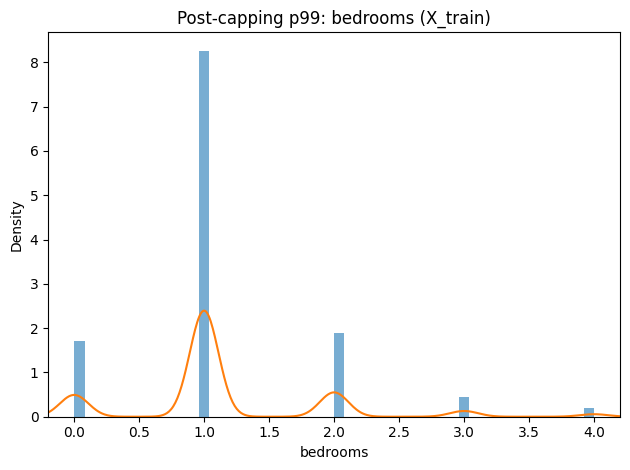

np.float64(4.0)

In [ ]:
transform_capping(variable, 99)

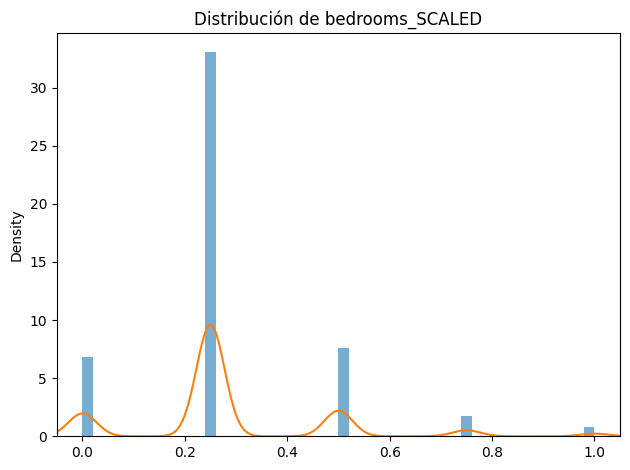

✅ 'bedrooms' → 'bedrooms_SCALED' | Min: 0.0000 | Max: 1.0000 | Mean: 0.2835


In [ ]:
transform_scaler(variable)

#### 4.2.5 Variable: beds

beds: 0 NULLS


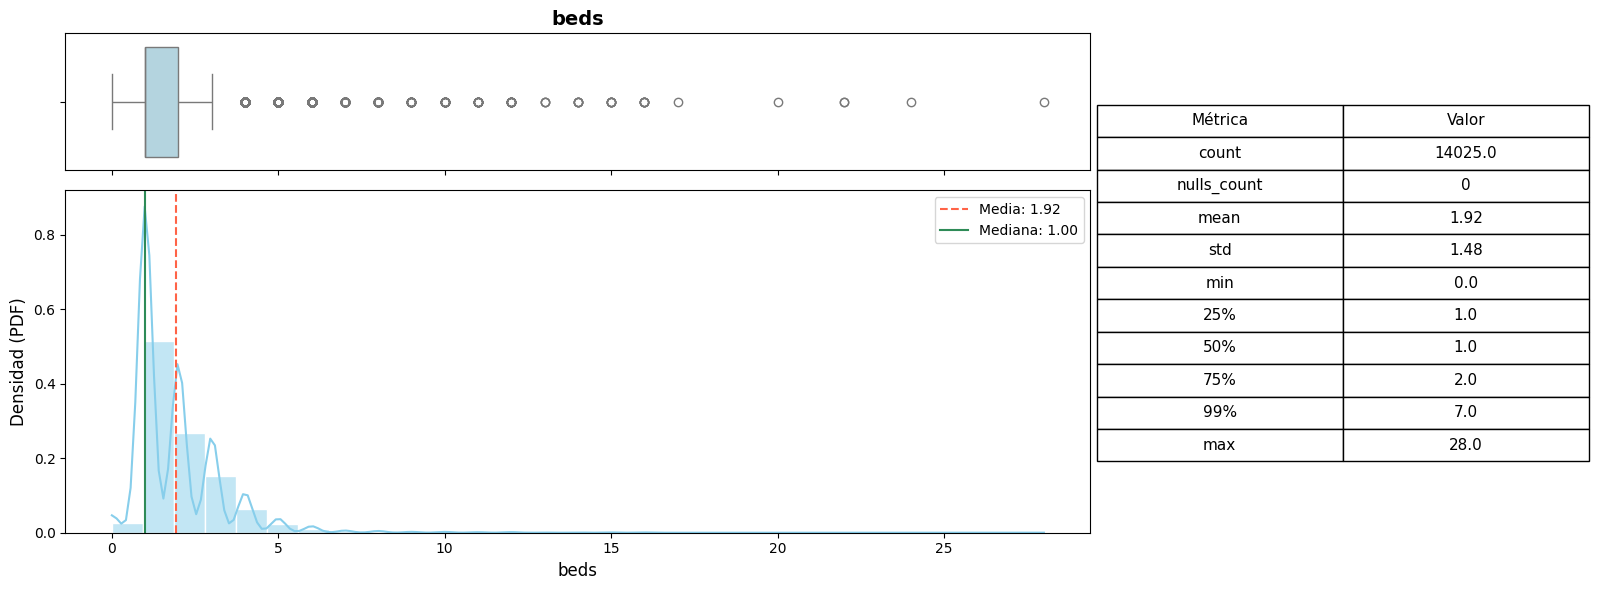

In [ ]:
variable = 'beds'

print(f'{variable}: {X_train[variable].isnull().sum()} NULLS')
plot_distribution(X_train, variable)

In [ ]:
analize_capping(variable)


📊 Variable: 'beds'


,Percentil,Valor,N casos (> p),Δ vs anterior,Δ% vs anterior
0,p90,4.0,593,NaN,nan%
1,p91,4.0,593,0.0,0.0%
2,p92,4.0,593,0.0,0.0%
3,p93,4.0,593,0.0,0.0%
4,p94,4.0,593,0.0,0.0%
5,p95,4.0,593,0.0,0.0%
6,p96,5.0,301,1.0,25.0%
7,p97,5.0,301,0.0,0.0%
8,p98,6.0,166,1.0,20.0%
9,p99,9.0,67,3.0,50.0%


✅ 'beds' capeada en p98 → umbral = 6.0000 (X_train)
✅ 'beds' capeada en p98 → umbral = 6.0000 (X_test)


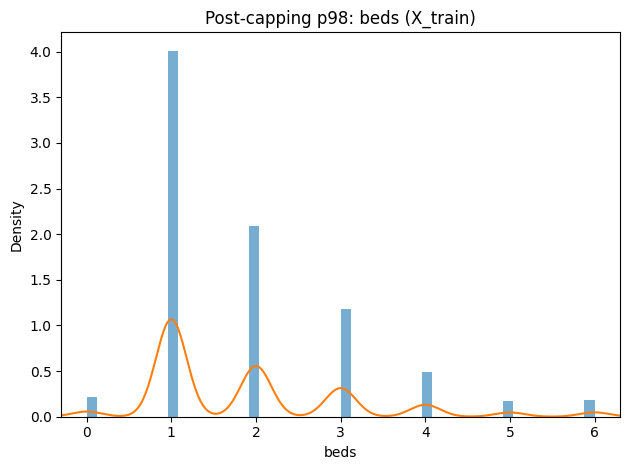

np.float64(6.0)

In [ ]:
transform_capping(variable, 98)

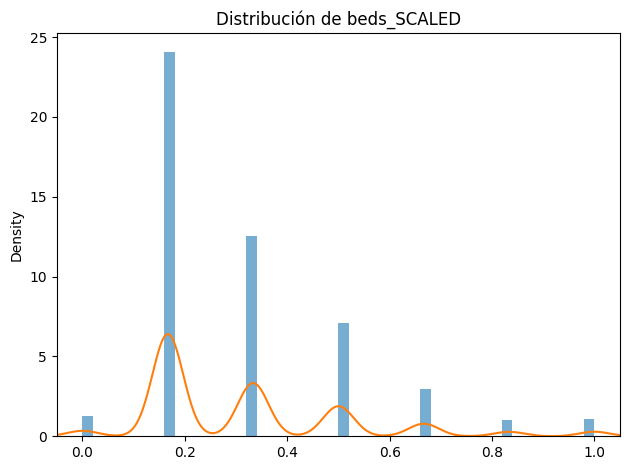

✅ 'beds' → 'beds_SCALED' | Min: 0.0000 | Max: 1.0000 | Mean: 0.3125


In [ ]:
transform_scaler(variable)

#### 4.2.6 Variable: minimum_nights

minimum_nights: 55 NULLS


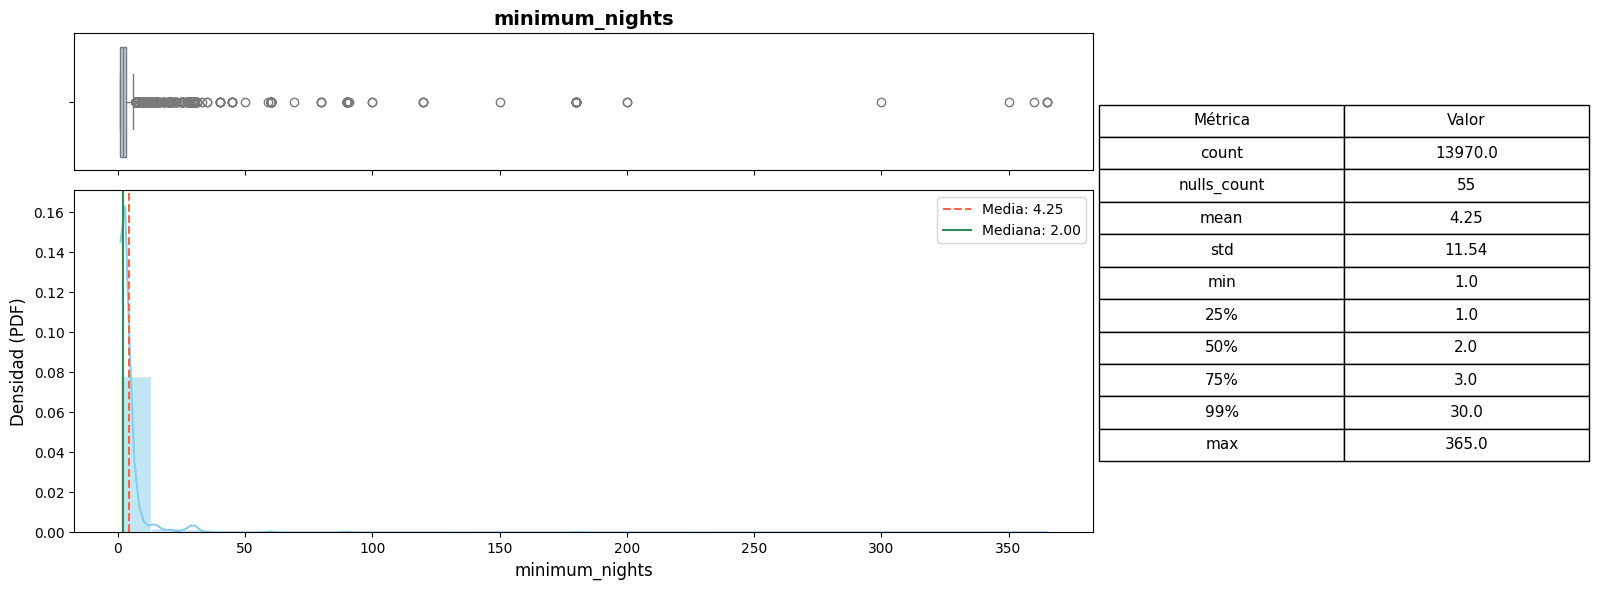

In [ ]:
variable = 'minimum_nights'

print(f'{variable}: {X_train[variable].isnull().sum()} NULLS')
plot_distribution(X_train, variable)

In [ ]:
# Primero tratamos los nulos, al ser solo 55 esta bien para este caso

median_val = X_train["minimum_nights"].median()
X_train["minimum_nights"] = X_train["minimum_nights"].fillna(median_val)
X_test["minimum_nights"]  = X_test["minimum_nights"].fillna(median_val)

print(f"✅ Nulos imputados con mediana = {median_val}")

✅ Nulos imputados con mediana = 2.0


In [ ]:
analize_capping(variable)


📊 Variable: 'minimum_nights'


,Percentil,Valor,N casos (> p),Δ vs anterior,Δ% vs anterior
0,p90,7.0,953,NaN,nan%
1,p91,7.0,953,0.0,0.0%
2,p92,7.0,953,0.0,0.0%
3,p93,7.0,953,0.0,0.0%
4,p94,10.0,748,3.0,42.86%
5,p95,14.0,620,4.0,40.0%
6,p96,15.0,480,1.0,7.14%
7,p97,20.0,411,5.0,33.33%
8,p98,28.0,273,8.0,40.0%
9,p99,60.0,54,32.0,114.29%


✅ 'minimum_nights' capeada en p95 → umbral = 14.0000 (X_train)
✅ 'minimum_nights' capeada en p95 → umbral = 14.0000 (X_test)


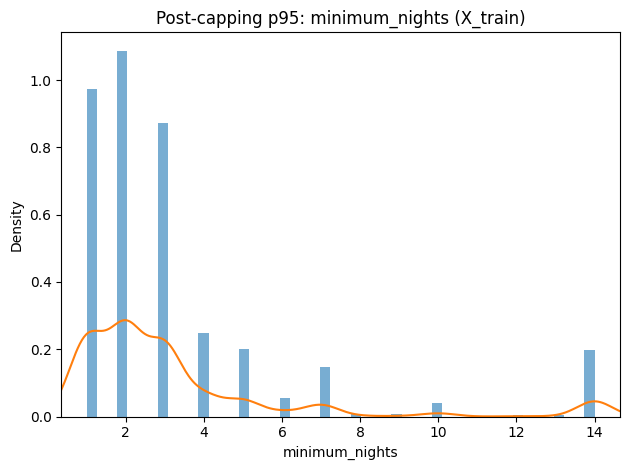

np.float64(14.0)

In [ ]:
transform_capping(variable, 95)

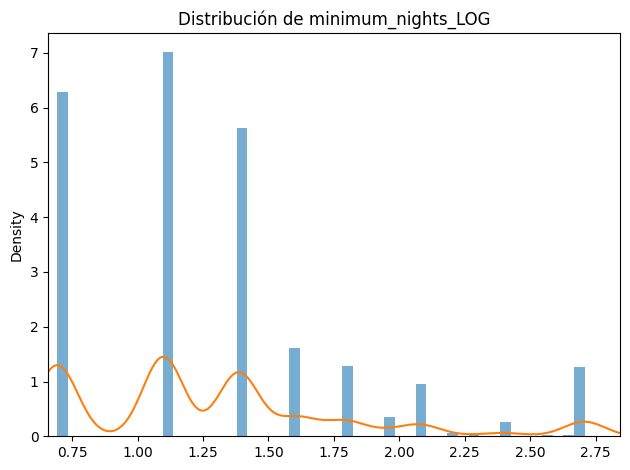

✅ 'minimum_nights' → 'minimum_nights_LOG' | Min: 0.6931 | Max: 2.7081 | Mean: 1.2840


In [ ]:
transform_log(variable)

#### 4.2.7 Variable: maximum_nights

maximum_nights: 55 NULLS


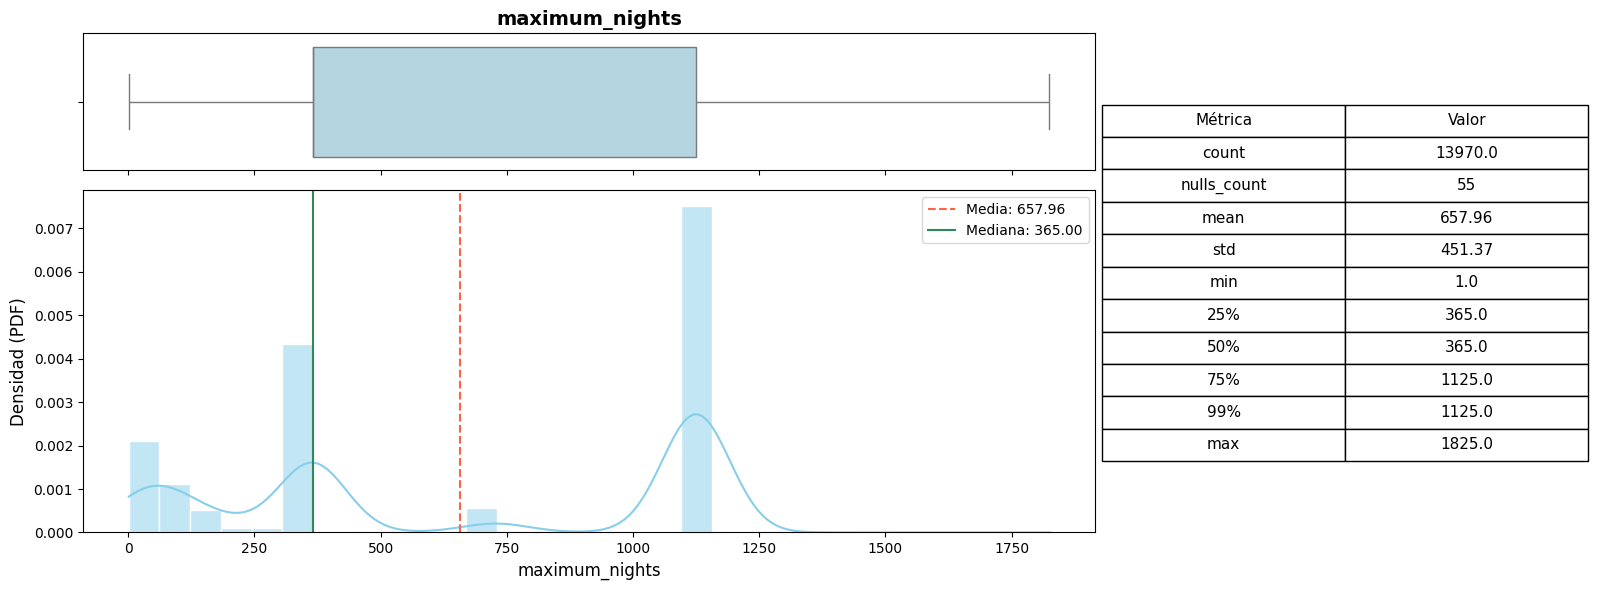

In [ ]:
variable = 'maximum_nights'

print(f'{variable}: {X_train[variable].isnull().sum()} NULLS')
plot_distribution(X_train, variable)

In [ ]:
# No le veo mucho sentido, la dropeamos
drop_non_relevant(variable)

✅ 'maximum_nights' → DROP de Train y Test


#### 4.2.8 Variable: maximum_minimum_nights

In [ ]:
# variable = 'maximum_minimum_nights'

# print(f'{variable}: {X_train[variable].isnull().sum()} NULLS')
# plot_distribution(X_train, variable)

#### 4.2.9 Variable: minimum_maximum_nights


In [ ]:
# variable = 'minimum_maximum_nights'

# print(f'{variable}: {X_train[variable].isnull().sum()} NULLS')
# plot_distribution(X_train, variable)

#### 4.2.10 Variable: minimum_nights_avg_ntm



In [ ]:
# variable = 'minimum_nights_avg_ntm'

# print(f'{variable}: {X_train[variable].isnull().sum()} NULLS')
# plot_distribution(X_train, variable)

#### 4.2.11 Variable: maximum_nights_avg_ntm



In [ ]:
# variable = 'maximum_nights_avg_ntm'

# print(f'{variable}: {X_train[variable].isnull().sum()} NULLS')
# plot_distribution(X_train, variable)

#### 4.2.12 Variable: review_scores_rating

review_scores_rating: 0 NULLS


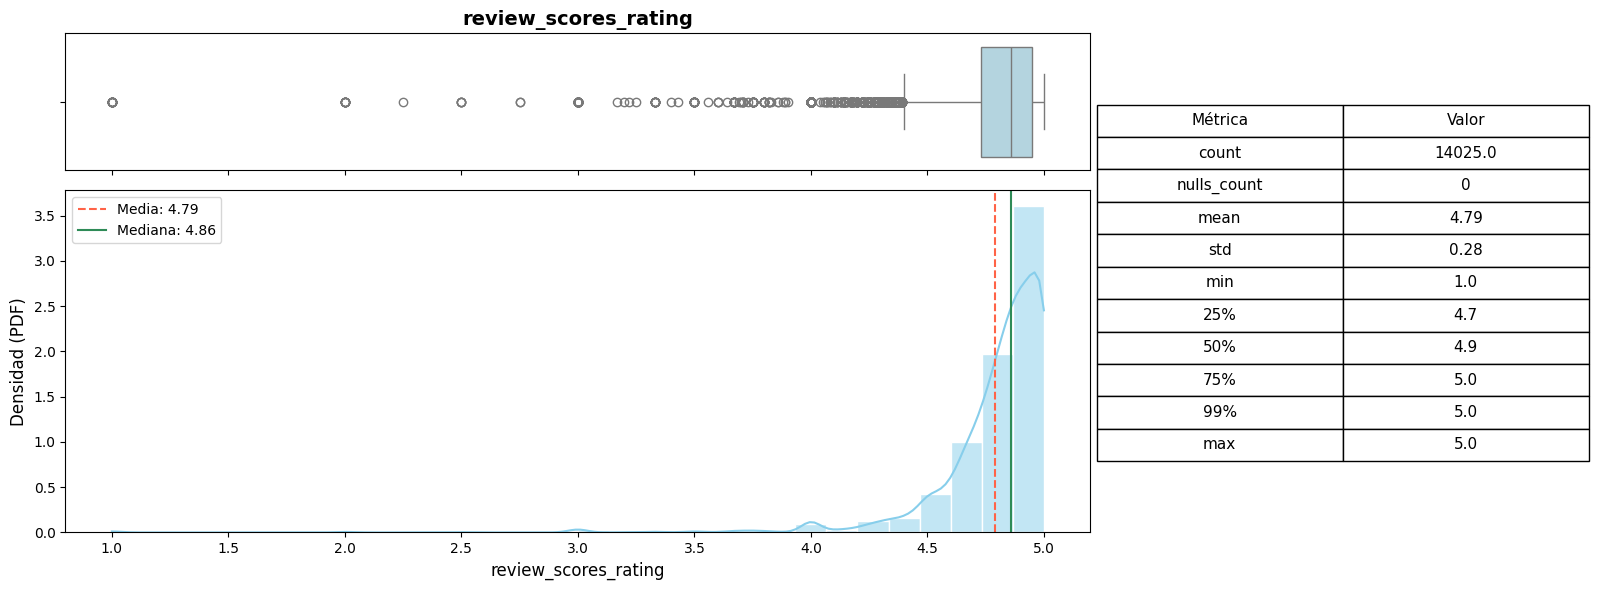

In [ ]:
variable = 'review_scores_rating'

print(f'{variable}: {X_train[variable].isnull().sum()} NULLS')
plot_distribution(X_train, variable)

In [ ]:
# Capeamos el limite inferior
cap_lower = 4.4

X_train["review_scores_rating"] = X_train["review_scores_rating"].clip(lower=cap_lower)
X_test["review_scores_rating"]  = X_test["review_scores_rating"].clip(lower=cap_lower)

print(f"   Nuevos valores: Min: {X_train['review_scores_rating'].min():.4f} | Max: {X_train['review_scores_rating'].max():.4f}")

   Nuevos valores: Min: 4.4000 | Max: 5.0000


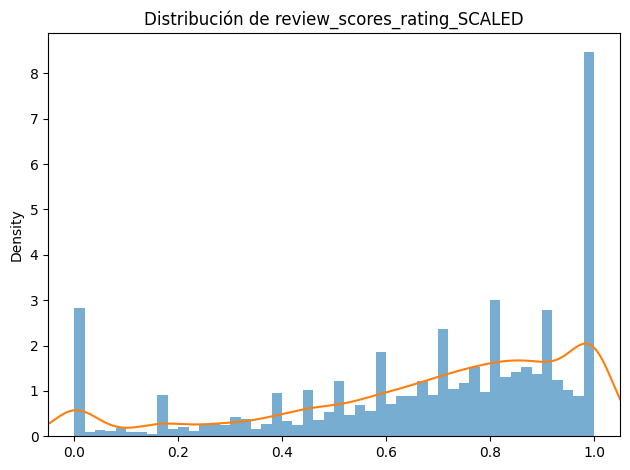

✅ 'review_scores_rating' → 'review_scores_rating_SCALED' | Min: 0.0000 | Max: 1.0000 | Mean: 0.6925


In [ ]:
transform_scaler(variable)

#### 4.2.13 Variable: review_scores_accuracy

In [ ]:
# variable = 'review_scores_accuracy'

# print(f'{variable}: {X_train[variable].isnull().sum()} NULLS')
# plot_distribution(X_train, variable)

#### 4.2.14 Variable: review_scores_cleanliness

In [ ]:
# variable = 'review_scores_cleanliness'

# print(f'{variable}: {X_train[variable].isnull().sum()} NULLS')
# plot_distribution(X_train, variable)

#### 4.2.15 Variable: review_scores_checkin

In [ ]:
# variable = 'review_scores_checkin'

# print(f'{variable}: {X_train[variable].isnull().sum()} NULLS')
# plot_distribution(X_train, variable)

#### 4.2.16 Variable: review_scores_communication

In [ ]:
# variable = 'review_scores_communication'

# print(f'{variable}: {X_train[variable].isnull().sum()} NULLS')
# plot_distribution(X_train, variable)

#### 4.2.17 Variable: review_scores_location

review_scores_location: 0 NULLS


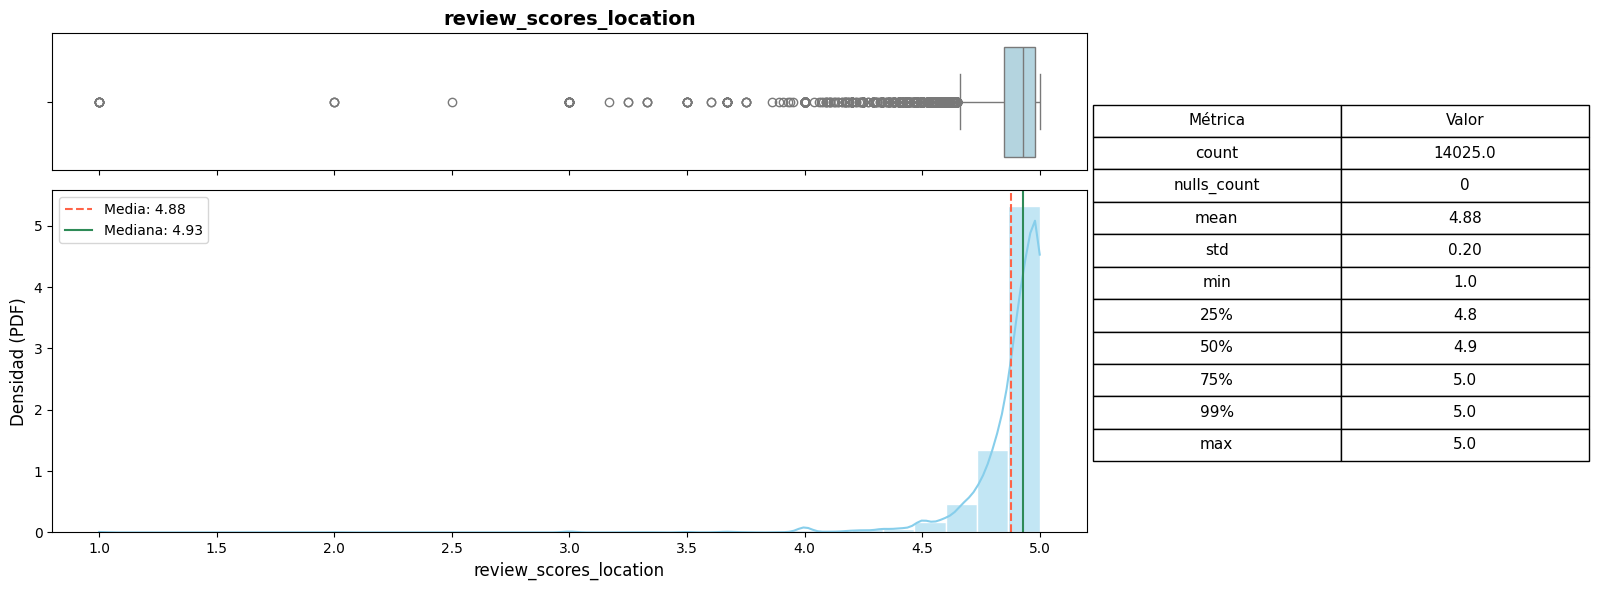

In [ ]:
variable = 'review_scores_location'

print(f'{variable}: {X_train[variable].isnull().sum()} NULLS')
plot_distribution(X_train, variable)

In [ ]:
# No la entiendo, se dropea
drop_non_relevant(variable)

✅ 'review_scores_location' → DROP de Train y Test


#### 4.2.18 Variable: review_scores_value

In [ ]:
# variable = 'review_scores_value'

# print(f'{variable}: {X_train[variable].isnull().sum()} NULLS')
# plot_distribution(X_train, variable)

#### 4.2.19 Variable: reviews_per_month

reviews_per_month: 0 NULLS


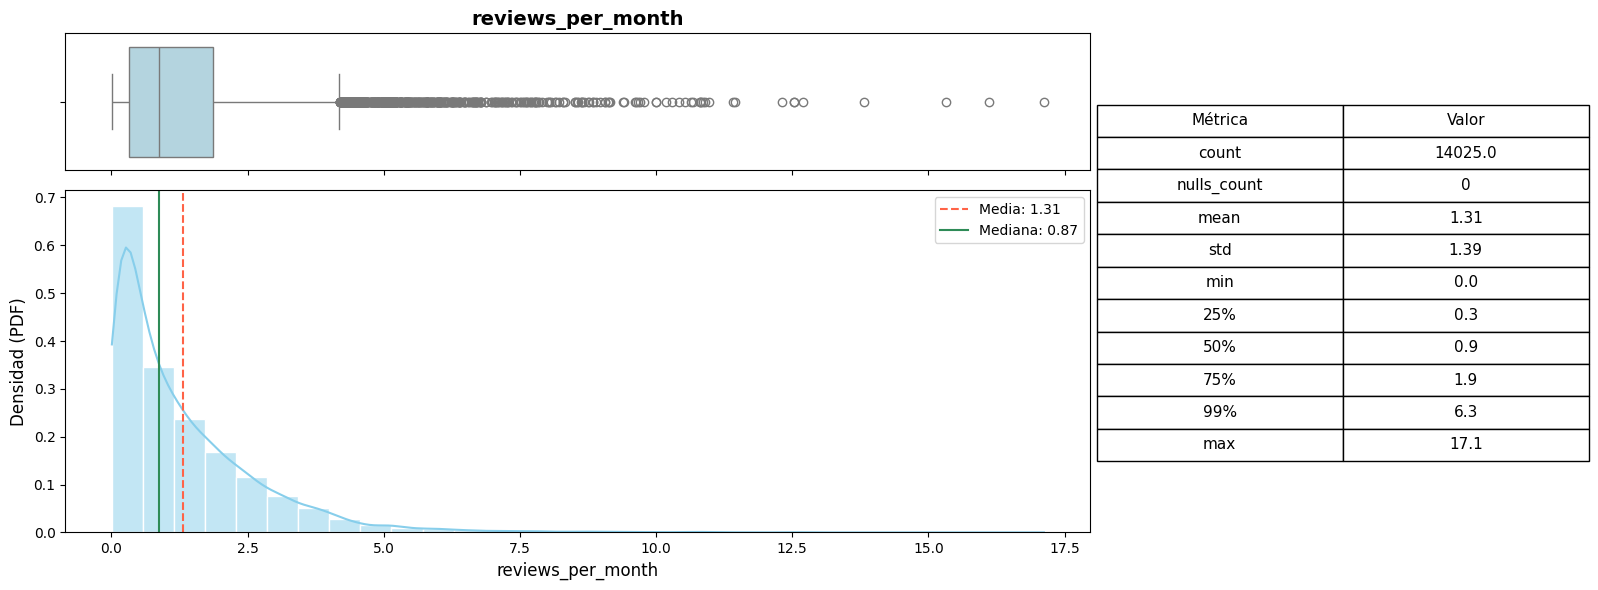

In [ ]:
variable = 'reviews_per_month'

print(f'{variable}: {X_train[variable].isnull().sum()} NULLS')
plot_distribution(X_train, variable)


In [ ]:
analize_capping(variable)


📊 Variable: 'reviews_per_month'


,Percentil,Valor,N casos (> p),Δ vs anterior,Δ% vs anterior
0,p90,3.0800,1394,NaN,nan%
1,p91,3.1900,1260,0.1100,3.57%
2,p92,3.3500,1115,0.1600,5.02%
3,p93,3.5100,976,0.1600,4.78%
4,p94,3.6900,841,0.1800,5.13%
5,p95,3.8900,697,0.2000,5.42%
6,p96,4.1300,556,0.2400,6.17%
7,p97,4.5100,419,0.3800,9.2%
8,p98,5.1452,281,0.6352,14.08%
9,p99,7.6652,71,2.5200,48.98%


✅ 'reviews_per_month' capeada en p98 → umbral = 5.1452 (X_train)
✅ 'reviews_per_month' capeada en p98 → umbral = 5.1452 (X_test)


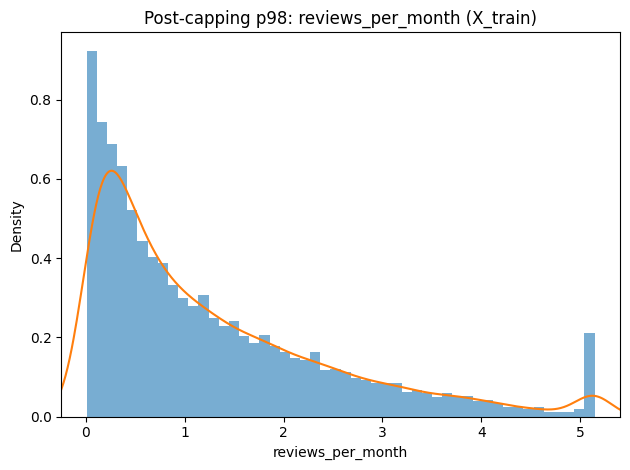

np.float64(5.145200000000004)

In [ ]:
transform_capping(variable, 98)

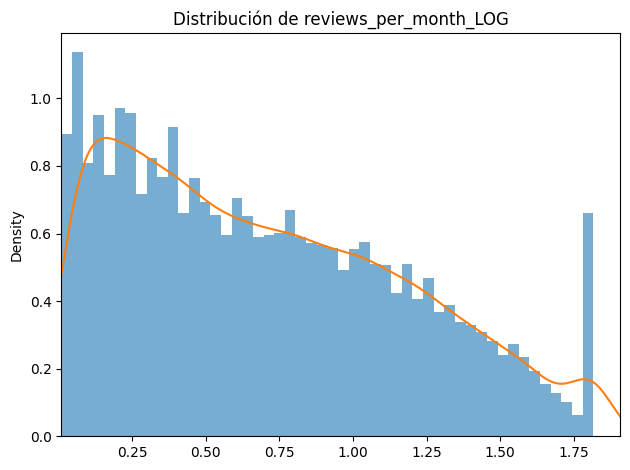

✅ 'reviews_per_month' → 'reviews_per_month_LOG' | Min: 0.0100 | Max: 1.8157 | Mean: 0.7000


In [ ]:
transform_log(variable)

### 4.3 String

In [ ]:
columns_str = X_train.select_dtypes(include=['object']).columns.tolist()
X_train[columns_str].sample(3)

,name,description,host_name,host_location,host_about,host_is_superhost,host_has_profile_pic,host_identity_verified,neighbourhood_cleansed,property_type,room_type,bathrooms_text,amenities
19615,Departamento con vista abierta,"Kick back and relax in this calm, stylish spac...",Federico,"Buenos Aires, Argentina",Hola Soy Federico de Buenos Aires trabajo en l...,t,t,t,Recoleta,Entire rental unit,Entire home/apt,1 bath,"[""HDTV"", ""Hair dryer"", ""Dedicated workspace"", ..."
23113,Departamento 2 ambientes .,Apartment located in the Belgrano neighborhood...,Cintia,"General Belgrano, Argentina",Hola me llamo Cintia y pongo mi departamento p...,f,t,t,Belgrano,Entire rental unit,Entire home/apt,1 bath,"[""Wifi"", ""Pets allowed"", ""Kitchen"", ""Fire exti..."
2507,"Monoambiente -Studio luminoso, moderno en Reco...","The studio is small, bright, quiet and modern....",Flavia,"Buenos Aires, Argentina",A raíz de haber viajado tanto por trabajo como...,f,t,t,Recoleta,Entire rental unit,Entire home/apt,1 bath,"[""Stainless steel oven"", ""Host greets you"", ""B..."


#### 4.3.1 Variable: name

In [ ]:
variable = 'name'

print(f'{variable}: {X_train[variable].isnull().sum()} NULLS')
X_train[variable].describe()

name: 0 NULLS


,name
count,14025
unique,13520
top,Departamento en Recoleta
freq,26


In [ ]:
X_train[variable].sample(10)

,name
5733,Petit departamento en zona residencial de Pale...
26007,RENT BEAUTIFUL APARTAMENT IN BS.AS
15267,PALERMO APARTMENT
22674,(2.2) Habitación privada. Enrique S. Discépolo -
8326,Apartamento en Edificio Crucero
8083,"Almagro : Luminoso departamento, todo equipado."
9931,Apto con cochera en Palermo cerca a La Rural
24909,"Large, Comfortable Apartment in the Heart of BA!"
23746,City Loft en La Boca: Un espacio único
6970,Departamento en pleno Recoleta One Bedroom


In [ ]:
# La dropeamos, no tiene mucho sentido.
drop_non_relevant(variable)

✅ 'name' → DROP de Train y Test


#### 4.3.2 Variable: description

In [ ]:
variable = 'description'

print(f'{variable}: {X_train[variable].isnull().sum()} NULLS')
X_train[variable].describe()

# Se puede jugar con NLP y hacer algo

description: 276 NULLS


,description
count,13749
unique,12537
top,MOT is the leading agency for short term renta...
freq,53


In [ ]:
X_test[variable].sample(5)

,description
9408,NaN
7170,"Excellent building located in Palermo Queens, ..."
4491,"Bright 70 m² apartment for up to 4 guests, on ..."
18940,"Stay in a private, bright and comfortable stud..."
24814,Excellent studio apartment in the heart of Pal...


In [ ]:
# La dropeamos, no tiene mucho sentido.
drop_non_relevant(variable)

✅ 'description' → DROP de Train y Test


#### 4.3.3 Variable: host_location

In [ ]:
variable = 'host_location'

print(f'{variable}: {X_train[variable].isnull().sum()} NULLS')
X_train[variable].describe()

# Estandarizar y ver

host_location: 2300 NULLS


,host_location
count,11725
unique,443
top,"Buenos Aires, Argentina"
freq,9542


In [ ]:
# Booleanizamos
transform_bool(variable, "Argentina", "_ARG")

✅ 'host_location' → 'host_location_ARG' | True: 92.6% | False: 7.4% | Nulls: 2300


In [ ]:
# Capturamos los nulls en otra variable
X_train["host_location_NULL"] = X_train["host_location_ARG"].isna()
X_test["host_location_NULL"]  = X_test["host_location_ARG"].isna()

print(f"✅ 'host_location_NULL' | True (eran nulos): {X_train['host_location_NULL'].mean():.1%}")

# Populamos los faltantes con NULL
X_train["host_location_ARG"] = X_train["host_location_ARG"].fillna(True).infer_objects(copy=False).astype(bool)
X_test["host_location_ARG"]  = X_test["host_location_ARG"].fillna(True).infer_objects(copy=False).astype(bool)

✅ 'host_location_NULL' | True (eran nulos): 16.4%


#### 4.3.4 Variable: host_name

In [ ]:
variable = 'host_name'

print(f'{variable}: {X_train[variable].isnull().sum()} NULLS')
X_train[variable].describe()

host_name: 0 NULLS


,host_name
count,14025
unique,2461
top,Federico
freq,239


In [ ]:
X_train[variable].sample(12, random_state=51)

,host_name
18334,Paula
11330,Agustina
23637,Maria Fernanda
17823,Nicolas
15244,Alejandro
21509,Gaston
21948,For Rent Argentina
9911,Matias
328,Philippe-Charles
22214,Leonardo


In [ ]:
# Identificamos si el host es una persona fisica o una empresa

keywords_empresa = ["hotel", "hostel", "apartment", "residencia",
                    "estudio", "administración", "rentals", "properties",
                    "apart", "rent", "desarrollos", "suit", "suites"]

data["host_is_business_BOOL"] = data["host_name"].str.lower().str.contains(
    "|".join(keywords_empresa), na=False)

# Actualizamos Train y Test
X_train["host_is_business_BOOL"] = data.loc[X_train.index, "host_is_business_BOOL"]
X_test["host_is_business_BOOL"]  = data.loc[X_test.index, "host_is_business_BOOL"]

# Dropeamos la columna original
X_train.drop(columns=["host_name"], inplace=True)
X_test.drop(columns=["host_name"], inplace=True)

print(f"✅ 'host_is_business_BOOL' agregada | True: {X_train['host_is_business_BOOL'].mean():.1%} | False: {(1 - X_train['host_is_business_BOOL'].mean()):.1%}")

✅ 'host_is_business_BOOL' agregada | True: 2.5% | False: 97.5%


In [ ]:
print(data["host_is_business_BOOL"].value_counts())
print(f"Proporción empresas: {data['host_is_business_BOOL'].mean():.1%}")

# Casos marcados como empresa — verificar que tengan sentido
print("\nEjemplos True:")
print(data[data["host_is_business_BOOL"]]["host_name"].value_counts().head(20))

# Casos False con nombres que podrían ser empresas — detectar falsos negativos
print("\nEjemplos False (muestra):")
print(data[~data["host_is_business_BOOL"]]["host_name"].sample(20).values)

host_is_business_BOOL
False    18225
True       475
Name: count, dtype: int64
Proporción empresas: 2.5%

Ejemplos True:
host_name
For Rent Argentina                   111
Signa Desarrollos                     38
Argentina Rent Aparts                 37
Top Rentals                           34
Rent Up                               24
Ayres Suites Apartments               23
RentAR                                19
Live SoHo Boutique Apartments         17
Sara De BH Rentals                    16
Alma Rentals                          16
Flippin Rent                          14
Come Here Rent                        11
La Vie Suite                          11
Administración Callao Residencias      8
Check Suites                           7
Tango Suites                           7
Apartments                             6
Apart Palermo                          6
VEve Apartments                        6
Masterkey Rentals                      5
Name: count, dtype: int64

Ejemplos False (muestra

#### 4.3.5 Variable: host_about


In [ ]:
variable = 'host_about'

print(f'{variable}: {X_train[variable].isnull().sum()} NULLS')
X_train[variable].describe()

host_about: 5403 NULLS


,host_about
count,8622
unique,4021
top,Amamos el mundo y nos encanta viajar también.\...
freq,103


In [ ]:
drop_non_relevant(variable)

✅ 'host_about' → DROP de Train y Test


#### 4.3.6 Variable: host_is_superhost


In [ ]:
variable = 'host_is_superhost'

print(f'{variable}: {X_train[variable].isnull().sum()} NULLS')
X_train[variable].value_counts(normalize=True).round(2)

# Transformar en booleana

host_is_superhost: 0 NULLS


,proportion
host_is_superhost,
f,0.53
t,0.47


In [ ]:
transform_bool(variable, "t")

✅ 'host_is_superhost' → 'host_is_superhost_BOOL' | True: 47.4% | False: 52.6% | Nulls: 0


#### 4.3.7 Variable: host_has_profile_pic


In [ ]:
variable = 'host_has_profile_pic'

print(f'{variable}: {X_train[variable].isnull().sum()} NULLS')
X_train[variable].value_counts()

# Transformar en booleana

host_has_profile_pic: 0 NULLS


,count
host_has_profile_pic,
t,13755
f,270


In [ ]:
transform_bool(variable, "t")

✅ 'host_has_profile_pic' → 'host_has_profile_pic_BOOL' | True: 98.1% | False: 1.9% | Nulls: 0


#### 4.3.8 Variable: host_identity_verified


In [ ]:
variable = 'host_identity_verified'

print(f'{variable}: {X_train[variable].isnull().sum()} NULLS')
X_train[variable].value_counts()

# Transformar en booleana

host_identity_verified: 0 NULLS


,count
host_identity_verified,
t,13945
f,80


In [ ]:
transform_bool(variable, "Argentina")

✅ 'host_identity_verified' → 'host_identity_verified_BOOL' | True: 0.0% | False: 100.0% | Nulls: 0


#### 4.3.9 Variable: neighbourhood_cleansed



In [ ]:
variable = 'neighbourhood_cleansed'

print(f'{variable}: {X_train[variable].isnull().sum()} NULLS')
X_train[variable].value_counts()

# Estandarizar y hacerla categorica

neighbourhood_cleansed: 0 NULLS


,count
neighbourhood_cleansed,
Palermo,4765
Recoleta,2075
San Nicolas,1029
Belgrano,670
Retiro,651
Monserrat,600
Almagro,546
Villa Crespo,478
Balvanera,476


In [ ]:
transform_freq(variable)

✅ 'neighbourhood_cleansed' → 'neighbourhood_cleansed_FREQ' | Min: 0.0001 | Max: 0.3398 | Mean: 0.1556
   Categorías mapeadas: 45 | NaNs en test: 0


#### 4.3.10 Variable: property_type


In [ ]:
variable = 'property_type'

print(f'{variable}: {X_train[variable].isnull().sum()} NULLS')
X_train[variable].value_counts()

# Estandarizar y hacerla categorica

property_type: 0 NULLS


,count
property_type,
Entire rental unit,9909
Entire condo,1721
Entire serviced apartment,533
Entire loft,385
Private room in rental unit,367
Private room in home,293
Entire home,202
Entire vacation home,115
Private room in condo,92


In [ ]:
# Transofrmamos en booleanas las publicaciones donse se alquile la unidad entera y no solo una room
transform_bool(variable, "Entire")

✅ 'property_type' → 'property_type_BOOL' | True: 92.3% | False: 7.7% | Nulls: 0


#### 4.3.11 Variable: room_type


In [ ]:
variable = 'room_type'

print(f'{variable}: {X_train[variable].isnull().sum()} NULLS')
X_train[variable].value_counts()


room_type: 0 NULLS


,count
room_type,
Entire home/apt,12972
Private room,998
Shared room,37
Hotel room,18


In [ ]:
# La dropeamos, es muy similar a la anterior

drop_non_relevant(variable)

✅ 'room_type' → DROP de Train y Test


#### 4.3.12 Variable: bathrooms_text


In [ ]:
variable = 'bathrooms_text'

print(f'{variable}: {X_train[variable].isnull().sum()} NULLS')
X_train[variable].value_counts()

bathrooms_text: 0 NULLS


,count
bathrooms_text,
1 bath,10171
1.5 baths,1493
2 baths,951
1 shared bath,322
1 private bath,239
2.5 baths,222
3 baths,132
1.5 shared baths,105
2 shared baths,83


In [ ]:
# La dropeamos, ya la tenemos en enteros

drop_non_relevant(variable)

✅ 'bathrooms_text' → DROP de Train y Test


#### 4.3.13 Variable: amenities


In [ ]:
variable = 'amenities'

print(f'{variable}: {X_train[variable].isnull().sum()} NULLS')
X_train[variable].describe()

amenities: 0 NULLS


,amenities
count,14025
unique,13756
top,"[""Kitchen"", ""Air conditioning"", ""Wifi"", ""TV""]"
freq,20


In [ ]:
data[variable].sample(10)

,amenities
26009,"[""Host greets you"", ""Bathtub"", ""Hair dryer"", ""..."
4777,"[""Host greets you"", ""Microwave"", ""Bienvenida ..."
20634,"[""Patio or balcony"", ""Coffee"", ""Hair dryer"", ""..."
16034,"[""Wifi"", ""Washer"", ""Self check-in"", ""Lockbox"",..."
794,"[""Clothing storage: closet and wardrobe"", ""Mic..."
1922,"[""Otro electric stove"", ""Host greets you"", ""Mi..."
14717,"[""Clothing storage: closet and wardrobe"", ""Bat..."
10195,"[""Microwave"", ""Bathtub"", ""Hair dryer"", ""Toaste..."
26312,"[""Dishes and silverware"", ""Refrigerator"", ""Cof..."
7265,"[""Host greets you"", ""Microwave"", ""Bathtub"", ""H..."


In [ ]:
amenity_counts = (
    X_train["amenities"]
    .apply(ast.literal_eval)
    .explode()
    .value_counts()
)

print(f"Total amenities únicas: {len(amenity_counts)}")
amenity_counts.head(40)

Total amenities únicas: 4594


,count
amenities,
Kitchen,13265
Hot water,12628
Dishes and silverware,12327
Wifi,12139
Cooking basics,11840
Hangers,11693
Bed linens,11356
Essentials,11022
Hair dryer,10678


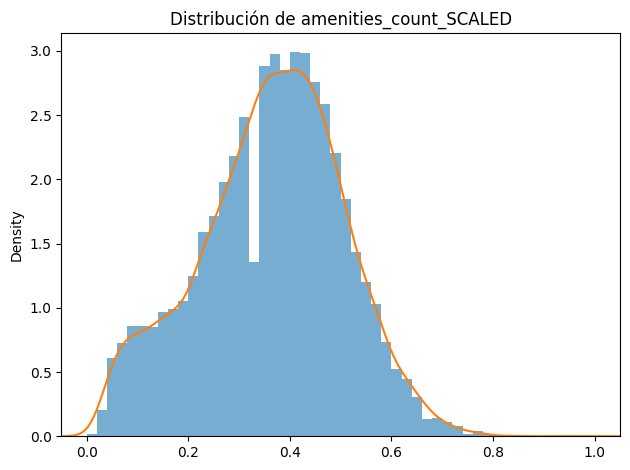

✅ 'amenities_count' → 'amenities_count_SCALED' | Min: 0.0000 | Max: 1.0000 | Mean: 0.3630
amenities rate: amenity_elevator_BOOL        0.69
amenity_ac_BOOL              0.62
amenity_workspace_BOOL       0.62
amenity_washer_BOOL          0.59
amenity_balcony_BOOL         0.58
amenity_bathtub_BOOL         0.54
amenity_parking_paid_BOOL    0.45
amenity_self_checkin_BOOL    0.35
amenity_pool_BOOL            0.28
amenity_pets_BOOL            0.19
amenity_gym_BOOL             0.14
amenity_parking_free_BOOL    0.04
dtype: float64


In [ ]:
# Parsear una vez
amenities_parsed_train = X_train["amenities"].apply(ast.literal_eval)
amenities_parsed_test  = X_test["amenities"].apply(ast.literal_eval)

# 1 — Count total
X_train["amenities_count"] = amenities_parsed_train.apply(len)
X_test["amenities_count"]  = amenities_parsed_test.apply(len)

# Escalo los conteos
transform_scaler("amenities_count")

# 2 — Flags de amenities con variabilidad media (ni muy comunes ni muy raras)
amenities_flags = {
    "amenity_pool_BOOL":          "Pool",
    "amenity_gym_BOOL":           "Gym",
    "amenity_bathtub_BOOL":       "Bathtub",
    "amenity_elevator_BOOL":      "Elevator",
    "amenity_ac_BOOL":            "Air conditioning",
    "amenity_parking_free_BOOL":  "Free parking on premises",
    "amenity_parking_paid_BOOL":  "Paid parking",
    "amenity_workspace_BOOL":     "Dedicated workspace",
    "amenity_balcony_BOOL":       "Patio or balcony",
    "amenity_self_checkin_BOOL":  "Self check-in",
    "amenity_pets_BOOL":          "Pets allowed",
    "amenity_washer_BOOL":        "Washer",
}

for col, keyword in amenities_flags.items():
    X_train[col] = amenities_parsed_train.apply(lambda lst: any(keyword.lower() in a.lower() for a in lst))
    X_test[col]  = amenities_parsed_test.apply(lambda lst: any(keyword.lower() in a.lower() for a in lst))

X_train.drop(columns=["amenities"], inplace=True)
X_test.drop(columns=["amenities"], inplace=True)

# Ver proporción de cada flag para validar variabilidad
print("amenities rate:", X_train[[c for c in X_train.columns if c.startswith("amenity_")]].mean().round(2).sort_values(ascending=False))

#### 4.3.14 Variable: has_availability


In [ ]:
# variable = 'has_availability'
# X_train[variable].value_counts()

# # No tiene sentido, dropear

#### 4.3.15 Variable: first_review


In [ ]:
variable = 'first_review'

print(f'{variable}: {X_train[variable].isnull().sum()} NULLS')
X_train[variable].describe()


first_review: 0 NULLS


,first_review
count,14025
mean,2022-03-15 02:01:52.427807232
min,2010-08-12 00:00:00
25%,2020-12-17 00:00:00
50%,2023-04-21 00:00:00
75%,2024-02-17 00:00:00
max,2025-01-25 00:00:00


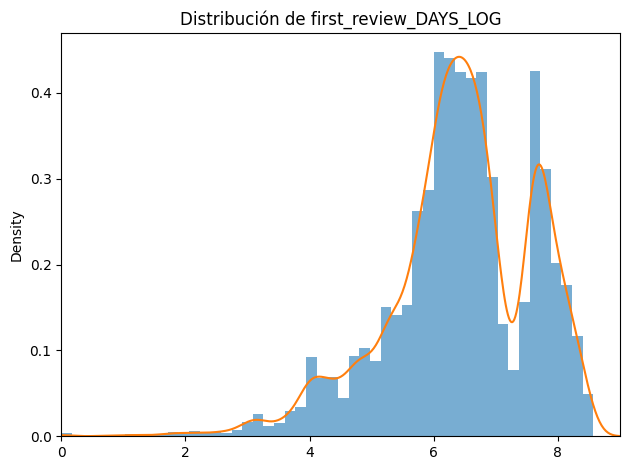

✅ 'first_review_DAYS' → 'first_review_DAYS_LOG' | Min: 0.0000 | Max: 8.5719 | Mean: 6.4140


In [ ]:
# Calculamos la distancia en dias a la fecha del scrap (2025-01-25)

transform_date(variable)

#### 4.3.16 Variable: last_review


In [ ]:
variable = 'last_review'

print(f'{variable}: {X_train[variable].isnull().sum()} NULLS')
X_train[variable].describe()


last_review: 0 NULLS


,last_review
count,14025
mean,2025-06-26 00:59:51.529411840
min,2013-01-06 00:00:00
25%,2025-08-01 00:00:00
50%,2025-12-17 00:00:00
75%,2026-01-07 00:00:00
max,2026-01-25 00:00:00


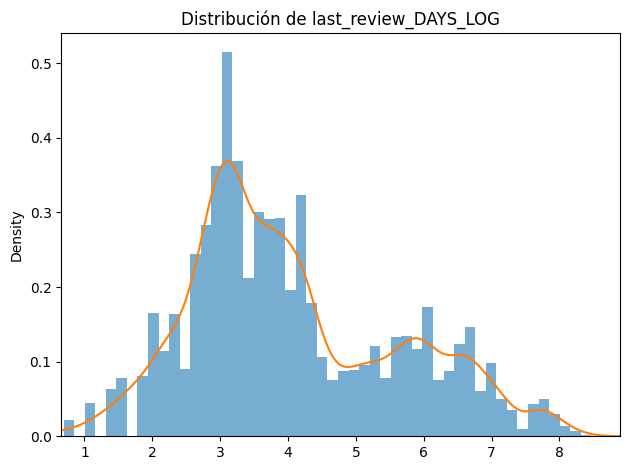

✅ 'last_review_DAYS' → 'last_review_DAYS_LOG' | Min: 0.6931 | Max: 8.4699 | Mean: 4.0616


In [ ]:
# Calculamos la distancia en dias a la fecha del scrap (2025-01-25)

transform_date(variable)

In [ ]:
X_train.columns

Index(['hosts_time_as_user_years_SCALED', 'hosts_time_as_host_years_SCALED',
       'host_listings_count_LOG', 'number_of_reviews_LOG', 'bathrooms_SCALED',
       'bedrooms_SCALED', 'beds_SCALED', 'minimum_nights_LOG',
       'review_scores_rating_SCALED', 'reviews_per_month_LOG',
       'host_location_ARG', 'host_location_NULL', 'host_is_business_BOOL',
       'host_is_superhost_BOOL', 'host_has_profile_pic_BOOL',
       'host_identity_verified_BOOL', 'neighbourhood_cleansed_FREQ',
       'property_type_BOOL', 'amenities_count_SCALED', 'amenity_pool_BOOL',
       'amenity_gym_BOOL', 'amenity_bathtub_BOOL', 'amenity_elevator_BOOL',
       'amenity_ac_BOOL', 'amenity_parking_free_BOOL',
       'amenity_parking_paid_BOOL', 'amenity_workspace_BOOL',
       'amenity_balcony_BOOL', 'amenity_self_checkin_BOOL',
       'amenity_pets_BOOL', 'amenity_washer_BOOL', 'first_review_DAYS_LOG',
       'last_review_DAYS_LOG'],
      dtype='object')

In [ ]:
X_test.head()

,hosts_time_as_user_years_SCALED,hosts_time_as_host_years_SCALED,host_listings_count_LOG,number_of_reviews_LOG,bathrooms_SCALED,bedrooms_SCALED,beds_SCALED,minimum_nights_LOG,review_scores_rating_SCALED,reviews_per_month_LOG,host_location_ARG,host_location_NULL,host_is_business_BOOL,host_is_superhost_BOOL,host_has_profile_pic_BOOL,host_identity_verified_BOOL,neighbourhood_cleansed_FREQ,property_type_BOOL,amenities_count_SCALED,amenity_pool_BOOL,amenity_gym_BOOL,amenity_bathtub_BOOL,amenity_elevator_BOOL,amenity_ac_BOOL,amenity_parking_free_BOOL,amenity_parking_paid_BOOL,amenity_workspace_BOOL,amenity_balcony_BOOL,amenity_self_checkin_BOOL,amenity_pets_BOOL,amenity_washer_BOOL,first_review_DAYS_LOG,last_review_DAYS_LOG
4806,0.6250,0.666667,1.791759,1.386294,0.571429,0.50,0.666667,2.708050,0.450000,0.039221,True,False,False,False,True,False,0.339750,True,0.350515,True,False,False,True,True,False,True,False,True,False,False,True,7.629490,7.772753
25594,0.1250,0.133333,0.693147,1.098612,0.285714,0.25,0.333333,1.609438,0.166667,0.067659,True,True,False,False,True,False,0.016257,True,0.278351,False,False,True,False,True,False,True,False,True,False,False,False,6.086775,6.542472
22781,0.5625,0.400000,3.367296,4.007333,0.285714,0.25,0.166667,1.386294,0.883333,1.342865,True,False,False,True,True,False,0.016542,True,0.412371,True,True,True,True,True,True,False,True,False,True,False,True,5.327876,3.332205
11409,0.1875,0.200000,1.098612,4.219508,0.285714,0.25,0.833333,0.693147,0.883333,0.996949,True,True,False,False,True,False,0.038930,True,0.463918,False,False,True,False,True,False,False,True,True,False,False,True,6.698268,3.583519
13516,0.3750,0.400000,1.098612,5.313206,0.285714,0.00,0.333333,1.098612,0.950000,1.252763,True,False,False,True,True,False,0.339750,True,0.587629,True,False,True,True,False,False,True,True,True,False,False,True,7.629004,3.135494


In [ ]:
print("Train y test iguales:", (X_train.columns == X_test.columns).all())
print(X_train.shape)
print(X_test.shape)
print("Nulls en Train y Test:", X_train.isnull().sum().sum(), X_test.isnull().sum().sum())

Train y test iguales: True
(14025, 33)
(4675, 33)
Nulls en Train y Test: 0 0


In [ ]:
print(X_train.columns.tolist())
print(X_train.shape)

['hosts_time_as_user_years_SCALED', 'hosts_time_as_host_years_SCALED', 'host_listings_count_LOG', 'number_of_reviews_LOG', 'bathrooms_SCALED', 'bedrooms_SCALED', 'beds_SCALED', 'minimum_nights_LOG', 'review_scores_rating_SCALED', 'reviews_per_month_LOG', 'host_location_ARG', 'host_location_NULL', 'host_is_business_BOOL', 'host_is_superhost_BOOL', 'host_has_profile_pic_BOOL', 'host_identity_verified_BOOL', 'neighbourhood_cleansed_FREQ', 'property_type_BOOL', 'amenities_count_SCALED', 'amenity_pool_BOOL', 'amenity_gym_BOOL', 'amenity_bathtub_BOOL', 'amenity_elevator_BOOL', 'amenity_ac_BOOL', 'amenity_parking_free_BOOL', 'amenity_parking_paid_BOOL', 'amenity_workspace_BOOL', 'amenity_balcony_BOOL', 'amenity_self_checkin_BOOL', 'amenity_pets_BOOL', 'amenity_washer_BOOL', 'first_review_DAYS_LOG', 'last_review_DAYS_LOG']
(14025, 33)


## 5 Conclusiones

### 5.1 Exploración y Comprensión
El dataset de AirBnB Buenos Aires contiene **27.025 listings** originales con **86 variables**. Tras un análisis de correlaciones, se identificaron múltiples pares de variables con correlación > 0.9 (e.g., `number_of_reviews_ltm` / `number_of_reviews_ly`, `availability_365` / `availability_eoy`), lo que evidenció una alta redundancia en el dataset original.

### 5.2 Criterio de Filtrado del Target
Para garantizar la validez de `availability_365` como variable target, se aplicó un filtro temporal conservando únicamente propiedades con `first_review` previo al 25-01-2025, asegurando al menos 365 días de actividad. Este criterio redujo el dataset a **14.025 observaciones**, aceptando el trade-off de excluir propiedades sin reviews.

### 5.3 Tratamiento de Variables
Se aplicaron transformaciones diferenciadas según la naturaleza de cada variable:
- **LOG**: variables con distribución sesgada a derecha y outliers extremos (`host_listings_count`, `number_of_reviews`, `minimum_nights`, `reviews_per_month`, `first_review_DAYS`, `last_review_DAYS`)
- **SCALED (MinMax)**: variables numéricas sin sesgo extremo (`hosts_time_as_user_years`, `hosts_time_as_host_years`, `bathrooms`, `bedrooms`, `beds`, `review_scores_rating`, `amenities_count`)
- **BOOL**: variables categóricas binarias o con baja cardinalidad (`host_is_superhost`, `host_has_profile_pic`, `host_identity_verified`, `property_type`, amenities específicas)
- **FREQ**: variables categóricas con alta cardinalidad (`neighbourhood_cleansed`)
- **Descartadas**: variables con leakage directo sobre el target, texto libre sin procesamiento viable, o con más del 50% de nulos

### 5.4 Feature Selection
La selección de variables se realizó combinando dos criterios:
1. **Correlación de Pearson**: detección y eliminación de variables con alta correlación lineal con el target (leakage) y entre sí (redundancia)
2. **Mutual Information**: validación de relaciones no lineales para variables que Pearson no captura

El dataset final para modelado quedó con **33 features** y **14.025 observaciones**.

# EXTRAS

## 6 PCA (Extra)
* Solo para explorar la técnica de reducción de dimensionalidad


Varianza explicada por componente:
  PC1: 0.594 (0.594 acumulada)
  PC2: 0.174 (0.767 acumulada)
  PC3: 0.147 (0.914 acumulada)
  PC4: 0.086 (1.000 acumulada)


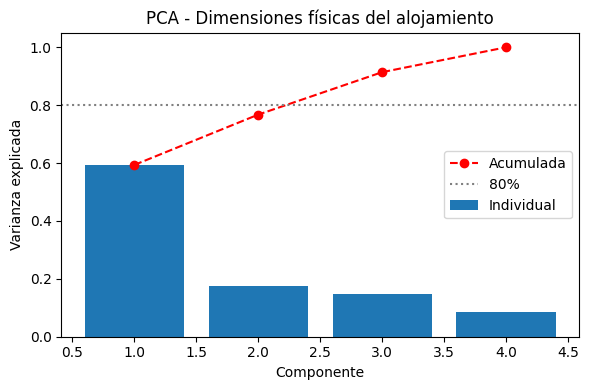

In [ ]:
# Features candidatas
pca_features = ['bathrooms_SCALED', 'bedrooms_SCALED', 'beds_SCALED', 'amenities_count_SCALED']

X_pca_input = X_train[pca_features]

# Fit PCA
pca = PCA()
pca.fit(X_pca_input)

# Varianza explicada
varianza = pca.explained_variance_ratio_
varianza_acum = np.cumsum(varianza)

print("Varianza explicada por componente:")
for i, (v, va) in enumerate(zip(varianza, varianza_acum)):
    print(f"  PC{i+1}: {v:.3f} ({va:.3f} acumulada)")

# Scree plot
fig, ax = plt.subplots(figsize=(6, 4))
ax.bar(range(1, len(varianza)+1), varianza, label='Individual')
ax.plot(range(1, len(varianza)+1), varianza_acum, 'o--', color='red', label='Acumulada')
ax.axhline(0.80, color='gray', linestyle=':', label='80%')
ax.set_xlabel('Componente')
ax.set_ylabel('Varianza explicada')
ax.set_title('PCA - Dimensiones físicas del alojamiento')
ax.legend()
plt.tight_layout()
plt.savefig('pca_scree_plot.png', dpi=150)
plt.show()

Se aplicó PCA sobre las variables de dimensión física del alojamiento (`bathrooms_SCALED`, `bedrooms_SCALED`, `beds_SCALED`, `amenities_count_SCALED`). Si bien PC1 explica el 59.4% de la varianza, alcanzar el umbral del 80% requiere 3 componentes sobre 4 originales, lo que representa una reducción marginal con pérdida de interpretabilidad. Por lo tanto, **se decide no reemplazar las features originales por componentes principales**.


## 7 Modelado (extra)

In [ ]:
# 1. Definir los modelos base (quitamos los hiperparámetros fijos que vamos a optimizar)
modelos = {
    'LinearRegression': LinearRegression(),
    'Ridge':            Ridge(),
    'Lasso':            Lasso(),
    'DecisionTree':     DecisionTreeRegressor(random_state=42),
    'RandomForest':     RandomForestRegressor(random_state=42, n_jobs=-1),
    'ExtraTrees':       ExtraTreesRegressor(random_state=42, n_jobs=-1),
    'GradientBoosting': GradientBoostingRegressor(random_state=42),
}

# 2. Definir los espacios de búsqueda (grids) para cada modelo
param_grids = {
    'LinearRegression': {}, # Sin hiperparámetros típicos para buscar
    'Ridge':            {'alpha': [0.01, 0.1, 1.0, 10.0, 100.0]},
    'Lasso':            {'alpha': [0.001, 0.01, 0.1, 1.0, 10.0]},
    'DecisionTree':     {'max_depth': [None, 5, 10, 20], 'min_samples_split': [2, 5, 10]},
    'RandomForest':     {'n_estimators': [50, 100, 200], 'max_depth': [None, 10, 20, 30], 'min_samples_split': [2, 5]},
    'ExtraTrees':       {'n_estimators': [50, 100, 200], 'max_depth': [None, 10, 20, 30], 'min_samples_split': [2, 5]},
    'GradientBoosting': {'n_estimators': [50, 100, 200], 'learning_rate': [0.01, 0.05, 0.1, 0.2], 'max_depth': [3, 5, 10]},
}

resultados = []

for nombre, modelo in modelos.items():
    print(f"\nOptimizando y entrenando {nombre}...")
    grid = param_grids[nombre]

    if grid: # Si el modelo tiene hiperparámetros definidos para buscar
        # RandomizedSearchCV busca combinaciones aleatorias dentro del grid
        search = RandomizedSearchCV(
            modelo,
            param_distributions=grid,
            n_iter=10, # Prueba 10 combinaciones aleatorias (auméntalo si tienes tiempo)
            cv=5,
            scoring='neg_root_mean_squared_error',
            n_jobs=-1,
            random_state=42
        )
        search.fit(X_train, y_train)

        # Extraemos el mejor modelo y sus métricas de validación cruzada
        mejor_modelo = search.best_estimator_
        cv_rmse_mean = -search.best_score_

        # Para sacar el desvío estándar de la mejor combinación
        indice_mejor = search.best_index_
        cv_rmse_std = search.cv_results_['std_test_score'][indice_mejor]

        print(f"  -> Mejores parámetros: {search.best_params_}")

    else:
        # Para modelos sin grid (como LinearRegression) usamos el flujo estándar
        mejor_modelo = modelo
        mejor_modelo.fit(X_train, y_train)
        cv_scores = cross_val_score(mejor_modelo, X_train, y_train, cv=5,
                                    scoring='neg_root_mean_squared_error', n_jobs=-1)
        cv_rmse_mean = -cv_scores.mean()
        cv_rmse_std = cv_scores.std()
        print("  -> Sin hiperparámetros a optimizar.")

    # Fit (ya hecho internamente en search.fit para el mejor modelo) y métricas sobre test
    y_pred = mejor_modelo.predict(X_test)

    resultados.append({
        'Modelo':       nombre,
        'CV_RMSE_mean': cv_rmse_mean,
        'CV_RMSE_std':  cv_rmse_std,
        'Test_RMSE':    np.sqrt(mean_squared_error(y_test, y_pred)),
        'Test_MAE':     mean_absolute_error(y_test, y_pred),
        'Test_R2':      r2_score(y_test, y_pred),
    })

df_resultados = pd.DataFrame(resultados).sort_values('Test_RMSE')
df_resultados = df_resultados.round(4)

print("\n=== RANKING DE MODELOS (OPTIMIZADOS) ===")
print(df_resultados.to_string(index=False))


Optimizando y entrenando LinearRegression...
  -> Sin hiperparámetros a optimizar.

Optimizando y entrenando Ridge...


/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_search.py:317: UserWarning: The total space of parameters 5 is smaller than n_iter=10. Running 5 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(


  -> Mejores parámetros: {'alpha': 100.0}

Optimizando y entrenando Lasso...


/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_search.py:317: UserWarning: The total space of parameters 5 is smaller than n_iter=10. Running 5 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(


  -> Mejores parámetros: {'alpha': 0.1}

Optimizando y entrenando DecisionTree...
  -> Mejores parámetros: {'min_samples_split': 10, 'max_depth': 5}

Optimizando y entrenando RandomForest...
  -> Mejores parámetros: {'n_estimators': 200, 'min_samples_split': 5, 'max_depth': None}

Optimizando y entrenando ExtraTrees...
  -> Mejores parámetros: {'n_estimators': 200, 'min_samples_split': 5, 'max_depth': None}

Optimizando y entrenando GradientBoosting...
  -> Mejores parámetros: {'n_estimators': 100, 'max_depth': 10, 'learning_rate': 0.05}

=== RANKING DE MODELOS (OPTIMIZADOS) ===
          Modelo  CV_RMSE_mean  CV_RMSE_std  Test_RMSE  Test_MAE  Test_R2
      ExtraTrees      103.5498       0.5628   102.1197   84.2179   0.1512
    RandomForest      104.6835       0.4569   102.6543   85.8310   0.1422
GradientBoosting      105.6880       0.3658   103.3264   85.5868   0.1310
LinearRegression      109.2565       0.6975   107.2244   91.6278   0.0642
           Lasso      109.2493       0.6724 